In [3]:
from moabb.datasets import BNCI2014001 # BCI-IV 2a dataset
from moabb.paradigms import MotorImagery
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace # Import TangentSpace for projection
from sklearn.svm import SVC # Import SVC for the SVM classifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Load the BCI-IV 2a dataset (9 individuals)
dataset = BNCI2014001()
dataset.subject_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# 2. Define the paradigm (Bandpass filter 8-32 Hz, extract epochs)
paradigm = MotorImagery(fmin=8.0, fmax=32.0)

# 3. Build the Riemannian Pipeline
# This computes covariance matrices, projects to Tangent Space, and applies SVM
pipeline = make_pipeline(
    Covariances(estimator='oas'),
    TangentSpace(metric='riemann'), # Project to tangent space
    SVC() # Apply Support Vector Machine
)

# 4. Run the evaluation across all 9 subjects
scores = []
for subject in dataset.subject_list:
    X, y, _ = paradigm.get_data(dataset, subjects=[subject])

    # 5-fold cross-validation per subject
    score = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    scores.append(np.mean(score))
    print(f"Subject {subject} Accuracy: {np.mean(score):.2f}")

print(f"Average Accuracy across 9 subjects: {np.mean(scores):.2f}")

ModuleNotFoundError: No module named 'moabb'

In [4]:
!pip install moabb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.1/279.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 6.9 MB/s eta 0:00:00


In [12]:
import numpy as np
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from pyriemann.estimation import Covariances
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

class TraceNormalizer(BaseEstimator, TransformerMixin):
    """
    Projects SPD matrices to the unit-trace hyperplane.
    Crucial for numerical stability of the Stein kernel determinant.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Divide each covariance matrix by its trace
        return np.array([x / np.trace(x) for x in X])

class SteinGramMatrix(BaseEstimator, TransformerMixin):
    def __init__(self, normalized=False, beta=0.5):
        self.normalized = normalized
        self.beta = beta
        self.X_train_ = None

    def fit(self, X, y=None):
        self.X_train_ = X
        return self

    def transform(self, X):
        N = len(X)
        M = len(self.X_train_)
        K = np.zeros((N, M))

        if self.normalized:
            log_det_X = np.array([np.linalg.slogdet(x)[1] for x in X])
            log_det_train = np.array([np.linalg.slogdet(y)[1] for y in self.X_train_])

        for i in range(N):
            for j in range(M):
                M_ij = (X[i] + self.X_train_[j]) / 2.0
                _, log_det_M = np.linalg.slogdet(M_ij)

                if self.normalized:
                    log_K_ij = -self.beta * log_det_M + (self.beta / 2.0) * log_det_X[i] + (self.beta / 2.0) * log_det_train[j]
                else:
                    log_K_ij = -self.beta * log_det_M

                K[i, j] = np.exp(log_K_ij)

        return K

In [ ]:
import numpy as np
from tqdm.auto import tqdm  # Works across notebook/terminal backends
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from pyriemann.estimation import Covariances
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

class SteinGramMatrix(BaseEstimator, TransformerMixin):
    def __init__(self, normalized=False, beta=0.5):
        self.normalized = normalized
        self.beta = beta
        self.X_train_ = None

    def fit(self, X, y=None):
        self.X_train_ = X
        return self

    def transform(self, X):
        N = len(X)
        M = len(self.X_train_)
        K = np.zeros((N, M))

        if self.normalized:
            log_det_X = np.array([np.linalg.slogdet(x)[1] for x in X])
            log_det_train = np.array([np.linalg.slogdet(y)[1] for y in self.X_train_])

        for i in range(N):
            for j in range(M):
                M_ij = (X[i] + self.X_train_[j]) / 2.0
                _, log_det_M = np.linalg.slogdet(M_ij)

                if self.normalized:
                    log_K_ij = -self.beta * log_det_M + (self.beta / 2.0) * log_det_X[i] + (self.beta / 2.0) * log_det_train[j]
                else:
                    log_K_ij = -self.beta * log_det_M

                K[i, j] = np.exp(log_K_ij)

        return K

# 1. Dataset Initialization (8-30 Hz)
dataset = BNCI2014001()
paradigm = MotorImagery(fmin=8.0, fmax=30.0)

# 2. Define the 30-fold 80/20 validation strategy for GridSearchCV
cv_strategy = ShuffleSplit(n_splits=30, test_size=0.2, random_state=42)

# Grid Search Parameters
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000]}

# 3. Pipeline Definitions (Added verbose=1 to track cross-validation folds)
pipeline_std = make_pipeline(
    Covariances(estimator='scm'),
    SteinGramMatrix(normalized=False, beta=0.5),
    SVC(kernel='precomputed')
)
grid_std = GridSearchCV(pipeline_std, param_grid, cv=cv_strategy, verbose=1, n_jobs=1)

pipeline_norm = make_pipeline(
    Covariances(estimator='scm'),
    SteinGramMatrix(normalized=True, beta=0.5),
    SVC(kernel='precomputed')
)
grid_norm = GridSearchCV(pipeline_norm, param_grid, cv=cv_strategy, verbose=1, n_jobs=1)

# 4. Evaluation Loop over subjects
results_std = []
results_norm = []

subjects_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Top-level progress bar wrapping the subject loop
for subject in tqdm(subjects_list, desc="Overall Subject Progress"):
    # BCI-IV 2a has two sessions: '0train' (Train) and '1test' (Test)
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])

    # Isolate Train and Test sets
    train_idx = metadata['session'] == '0train' # Corrected session name
    test_idx = metadata['session'] == '1test'   # Corrected session name

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Train and evaluate Standard Stein
    print(f"\n--- Processing Subject {subject}: Standard Stein ---")
    grid_std.fit(X_train, y_train)
    acc_std = grid_std.score(X_test, y_test)
    results_std.append(acc_std)

    # Train and evaluate Normalized Stein
    print(f"\n--- Processing Subject {subject}: Normalized Stein ---")
    grid_norm.fit(X_train, y_train)
    acc_norm = grid_norm.score(X_test, y_test)
    results_norm.append(acc_norm)

    print(f"\nSub {subject} Results - Std: {acc_std*100:.2f}% | Norm: {acc_norm*100:.2f}%")
    print("="*60)

print(f"\nFinal Mean Std: {np.mean(results_std)*100:.2f}% | Final Mean Norm: {np.mean(results_norm)*100:.2f}%")

Overall Subject Progress:   0%|          | 0/9 [00:00<?, ?it/s]


--- Processing Subject 1: Standard Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

--- Processing Subject 1: Normalized Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

Sub 1 Results - Std: 71.18% | Norm: 78.12%

--- Processing Subject 2: Standard Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

--- Processing Subject 2: Normalized Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

Sub 2 Results - Std: 50.69% | Norm: 47.57%

--- Processing Subject 3: Standard Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

--- Processing Subject 3: Normalized Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

Sub 3 Results - Std: 66.67% | Norm: 81.25%

--- Processing Subject 4: Standard Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 fits

--- Processing Subject 4: Normalized Stein ---
Fitting 30 folds for each of 5 candidates, totalling 150 f

In [16]:
dataset = BNCI2014001()
# EXACT physiological window for BCI-IV 2a to match reference [12] constraints
paradigm = MotorImagery(fmin=8.0, fmax=30.0, tmin=0.5, tmax=3.5)

cv_strategy = ShuffleSplit(n_splits=30, test_size=0.2, random_state=42)
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000]}

# 3. Pipeline Definitions (Added TraceNormalizer)
# We use 'oas' (Oracle Approximating Shrinkage) to guarantee strictly positive eigenvalues
pipeline_std = make_pipeline(
    Covariances(estimator='oas'),
    TraceNormalizer(),
    SteinGramMatrix(normalized=False, beta=0.5),
    SVC(kernel='precomputed')
)
grid_std = GridSearchCV(pipeline_std, param_grid, cv=cv_strategy, n_jobs=-1)

pipeline_norm = make_pipeline(
    Covariances(estimator='oas'),
    TraceNormalizer(),
    SteinGramMatrix(normalized=True, beta=0.5),
    SVC(kernel='precomputed')
)
grid_norm = GridSearchCV(pipeline_norm, param_grid, cv=cv_strategy, n_jobs=-1)

# 4. Evaluation Loop
results_std = []
results_norm = []

for subject in tqdm([1, 2, 3, 4, 5, 6, 7, 8, 9], desc="Processing Subjects"):
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])

    train_idx = metadata['session'] == '0train'
    test_idx = metadata['session'] == '1test'

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    grid_std.fit(X_train, y_train)
    acc_std = grid_std.score(X_test, y_test)
    results_std.append(acc_std)

    grid_norm.fit(X_train, y_train)
    acc_norm = grid_norm.score(X_test, y_test)
    results_norm.append(acc_norm)

    print(f"Sub {subject} - Std: {acc_std*100:.2f}% | Norm: {acc_norm*100:.2f}%")

print(f"\nMean Std: {np.mean(results_std)*100:.2f}% | Mean Norm: {np.mean(results_norm)*100:.2f}%")

Processing Subjects:   0%|          | 0/9 [00:00<?, ?it/s]

Sub 1 - Std: 81.94% | Norm: 85.07%
Sub 2 - Std: 39.58% | Norm: 45.83%
Sub 3 - Std: 75.00% | Norm: 79.86%
Sub 4 - Std: 56.60% | Norm: 60.42%
Sub 5 - Std: 38.19% | Norm: 41.67%
Sub 6 - Std: 43.06% | Norm: 55.90%
Sub 7 - Std: 78.47% | Norm: 78.82%
Sub 8 - Std: 75.69% | Norm: 82.99%
Sub 9 - Std: 72.92% | Norm: 79.51%

Mean Std: 62.38% | Mean Norm: 67.79%


In [18]:
s = 2

[[[  1.66593879   0.32625041  -1.01578302 ...  -6.82768084  -9.48094371
   -10.68472997]
  [ -1.39623788  -3.04630751  -4.51317585 ... -10.29300772 -10.31123315
    -8.81366802]
  [ -0.66225173  -2.68412967  -4.34866543 ...  -9.28237914 -11.07040292
   -11.37463772]
  ...
  [  2.30116341   1.64629218   1.25500461 ...  -9.79761662 -12.18859686
   -13.09228443]
  [  3.72991547   3.20828438   2.77902064 ...  -6.32937675 -10.80522202
   -13.97048313]
  [  3.98498724   4.01318249   3.74479989 ...  -5.90999528  -8.36411752
    -9.37778077]]

 [[  1.9042247    2.07821646   1.28138138 ...   2.63940885   4.1261604
     5.55037622]
  [  0.44591781   0.61328268   0.5381945  ...  -0.32889448   0.24303471
     1.4552679 ]
  [  1.69366079   1.41297229   0.55886009 ...  -0.36788604   0.9000361
     2.69922596]
  ...
  [ -3.56303136  -4.294411    -4.72515924 ...   0.81610512  -0.88631676
    -1.9070943 ]
  [ -4.66749123  -4.45412538  -3.95146522 ...   3.54976422   1.89789389
     0.62419536]
  [ -4.11

In [5]:
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from pyriemann.estimation import Covariances
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery
import mne

class ButterworthMotorImagery(MotorImagery):
    """
    Custom MotorImagery paradigm that uses a 5th order Butterworth filter.
    """
    def preprocess_raw(self, raw, dataset, fitting_config=None):
        # 1. Apply the Butterworth 5th order filter using MNE
        iir_params = dict(order=5, ftype='butter')
        raw.filter(
            l_freq=self.fmin,
            h_freq=self.fmax,
            method='iir',
            iir_params=iir_params,
            verbose=False
        )
        # 2. Continue with default preprocessing
        super().preprocess_raw(raw, dataset, fitting_config)

class MicrovoltScaler(BaseEstimator, TransformerMixin):
    """Scales EEG data from Volts to Microvolts to ensure stable log-determinants."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X * 1e6

class SteinGramMatrix(BaseEstimator, TransformerMixin):
    def __init__(self, normalized=False, beta=0.5):
        self.normalized = normalized
        self.beta = beta
        self.X_train_ = None

    def fit(self, X, y=None):
        self.X_train_ = X
        return self

    def transform(self, X):
        N, M = len(X), len(self.X_train_)
        K = np.zeros((N, M))
        if self.normalized:
            log_det_X = np.array([np.linalg.slogdet(x)[1] for x in X])
            log_det_train = np.array([np.linalg.slogdet(y)[1] for y in self.X_train_])
        for i in range(N):
            for j in range(M):
                M_ij = (X[i] + self.X_train_[j]) / 2.0
                _, log_det_M = np.linalg.slogdet(M_ij)
                if self.normalized:
                    log_K_ij = -self.beta * log_det_M + (self.beta / 2.0) * log_det_X[i] + (self.beta / 2.0) * log_det_train[j]
                else:
                    log_K_ij = -self.beta * log_det_M
                K[i, j] = np.exp(log_K_ij)
        return K

# 1. Dataset Initialization with CUSTOM Paradigm
dataset = BNCI2014001()
paradigm = ButterworthMotorImagery(fmin=8.0, fmax=30.0, tmin=0.5, tmax=2.5)

cv_strategy = ShuffleSplit(n_splits=30, test_size=0.2, random_state=42)
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000]}

# 2. Pipeline Definitions
# pipeline_std = make_pipeline(MicrovoltScaler(), Covariances(estimator='scm'), SteinGramMatrix(normalized=False), SVC(kernel='precomputed'))
pipeline_std = make_pipeline(Covariances(estimator='scm'), SteinGramMatrix(normalized=False), SVC(kernel='precomputed'))
grid_std = GridSearchCV(pipeline_std, param_grid, cv=cv_strategy, n_jobs=-1)

# pipeline_norm = make_pipeline(MicrovoltScaler(), Covariances(estimator='scm'), SteinGramMatrix(normalized=True), SVC(kernel='precomputed'))
pipeline_norm = make_pipeline(Covariances(estimator='scm'), SteinGramMatrix(normalized=True), SVC(kernel='precomputed'))
grid_norm = GridSearchCV(pipeline_norm, param_grid, cv=cv_strategy, n_jobs=-1)

# 3. Evaluation Loop
results_std, results_norm = [], []
for subject in tqdm([1, 2, 3, 4, 5, 6, 7, 8, 9], desc='Processing Subjects'):
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])
    train_idx, test_idx = metadata['session'] == '0train', metadata['session'] == '1test'
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    grid_std.fit(X_train, y_train)
    results_std.append(grid_std.score(X_test, y_test))

    grid_norm.fit(X_train, y_train)
    results_norm.append(grid_norm.score(X_test, y_test))

    print(f'Sub {subject} - Std: {results_std[-1]*100:.2f}% | Norm: {results_norm[-1]*100:.2f}%')

print(f'\nFinal Mean Std: {np.mean(results_std)*100:.2f}% | Final Mean Norm: {np.mean(results_norm)*100:.2f}%')

/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


MNE_DATA is not already configured. It will be set to default location in the home directory - /Users/rishabhkumar/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(






























































































100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 31.6GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value a

Sub 1 - Std: 25.00% | Norm: 80.90%


/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
















































































100%|█████████████████████████████████████| 43.1M/43.1M [00:00<00:00, 34.1GB/s]
SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_h

...

Sub 7 - Std: 25.00% | Norm: 75.00%


/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(




















































































































100%|█████████████████████████████████████| 45.0M/45.0M [00:00<00:00, 34.0GB/s]
SHA256 hash of downloaded file: 7a4b3bd602d5bc307d3f4527fca2cf076659e94aca584dd64f6286fd413

Sub 8 - Std: 37.15% | Norm: 79.51%


/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bnci-horizon-2020.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(






































































































100%|█████████████████████████████████████| 44.8M/44.8M [00:00<00:00, 33.0GB/s]
SHA256 hash of downloaded file: b28d8a262c779c8cad9cc80ee6aa9c5691cfa6617c03befe490a090347ebd15c
Use this

Sub 9 - Std: 25.00% | Norm: 85.42%

Final Mean Std: 28.86% | Final Mean Norm: 65.97%


Final Mean Std: 28.86% | Final Mean Norm: 65.97%
Default filter parameters: [[8.0, 30.0]]


In [3]:
from moabb.paradigms import MotorImagery
import mne

class ButterworthMotorImagery(MotorImagery):
    """
    Custom MotorImagery paradigm that uses a 5th order Butterworth filter.
    """
    def preprocess_raw(self, raw, dataset, fitting_config=None):
        # 1. Apply the Butterworth 5th order filter using MNE
        # We set l_freq and h_freq based on the paradigm's initialization (fmin, fmax)
        iir_params = dict(order=5, ftype='butter')
        raw.filter(
            l_freq=self.fmin,
            h_freq=self.fmax,
            method='iir',
            iir_params=iir_params,
            verbose=False
        )

        # 2. Continue with default preprocessing (like resampling if specified)
        super().preprocess_raw(raw, dataset, fitting_config)

# Example usage:
custom_paradigm = ButterworthMotorImagery(fmin=8.0, fmax=30.0)
print(f"Created custom paradigm: {custom_paradigm}")

<frozen importlib._bootstrap>:219: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:219: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:219: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/Users/rishabhkumar/miniconda3/envs/kernel-experiments/lib/python3.8/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
Choosing from all possible events


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Created custom paradigm: <__main__.ButterworthMotorImagery object at 0x119482eb0>


In [2]:
!pip install moabb

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Using cached tomli-2.4.0-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.8/563.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 9.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.2 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 2.7 MB/s eta 0:00:00a 0:00:01m
Using cached tomli-2.4.0-py3-none-any.whl (14 kB)
  Created wheel for pyriemann: filename=pyriemann-0.5-py2.py3-none-any.whl size=107750 sha256=250bb2f69d1af8fdc54ab7daba80618ce3c5e65de441e29676950bf0f392a543
  Stored in directory: /Users/rishabhkumar/Library/Caches/pip/wheels/5e/a5/b5/41733b2ab0077847e2c58b67294f3c27f9824eb17b0286e

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

class SteinKernelTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, beta=0.5, normalized=True):
        self.beta = beta
        self.normalized = normalized
        self.X_train_ = None

    def fit(self, X, y=None):
        # Simply store training covariance matrices
        self.X_train_ = X
        return self

    def transform(self, X):
        # X: (n_samples, n_channels, n_channels)
        # self.X_train_: (m_samples, n_channels, n_channels)
        N = X.shape[0]
        M = self.X_train_.shape[0]
        K = np.zeros((N, M))
        
        # Rigorous computation of log-determinants for Stein distance
        log_det_X = np.array([np.linalg.slogdet(x)[1] for x in X])
        log_det_train = np.array([np.linalg.slogdet(x)[1] for x in self.X_train_])

        for i in range(N):
            for j in range(M):
                # Midpoint matrix for Jensen-Bregman Log-Det Divergence
                mean_mat = 0.5 * (X[i] + self.X_train_[j])
                _, log_det_mean = np.linalg.slogdet(mean_mat)
                
                if self.normalized:
                    # Normalized Stein Kernel (S-Divergence based)
                    log_K = -self.beta * (log_det_mean - 0.5 * log_det_X[i] - 0.5 * log_det_train[j])
                else:
                    log_K = -self.beta * log_det_mean
                
                K[i, j] = np.exp(log_K)
        return K

# Corrected Pipeline
pipeline = Pipeline([
    ('scaler', MicrovoltScaler()), # Essential for numerical stability of det
    ('cov', Covariances(estimator='scm')),
    ('kernel', SteinKernelTransformer(beta=0.5, normalized=True)),
    ('svc', SVC(kernel='precomputed'))
])

pipeline_oas = Pipeline([
    ('scaler', MicrovoltScaler()),
    ('cov', Covariances(estimator='oas')), # OAS for guaranteed positive definiteness
    ('kernel', SteinKernelTransformer(beta=0.5, normalized=True)),
    ('svc', SVC(kernel='precomputed'))
])
best_c = {'1': 10, '2': 10, '3': 10, '4': 10, '5': 10, '6': 10, '7': 10, '8': 10, '9': 10}
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(pipeline_oas, param_grid, cv=cv_strategy, n_jobs=1)
 # Default to C=10 if grid search fails
for subject in tqdm([1, 2, 3, 4, 5, 6, 7, 8, 9], desc='Processing Subjects'):
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])
    train_idx = metadata['session'] == '0train'
    test_idx = metadata['session'] == '1test'
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    grid.fit(X_train, y_train)
    best_c[subject] = grid.best_params_['svc__C'] if hasattr(grid, "best_params_") else 10
    
# Use best C from an already-fitted grid search (fallback to 10 if unavailable)


def make_pipeline(c, estimator='oas', normalized=True):
    return Pipeline([
        # ('scaler', MicrovoltScaler()), # Optional: Uncomment if scaling is desired
        ('cov', Covariances(estimator=estimator)),
        ('kernel', SteinKernelTransformer(beta=0.5, normalized=normalized)),
        ('svc', SVC(kernel='precomputed', C=c))
    ])

pipeline = make_pipeline(best_c)

# Param grid remains the same for C optimization


In [13]:
## Test the pipeline on a single subject to ensure it runs without errors
import warnings

warnings.filterwarnings("ignore")

dataset = BNCI2014001()
paradigm = ButterworthMotorImagery(fmin=8.0, fmax=30.0, tmin=0.5, tmax=2.5)
X, y, metadata = paradigm.get_data(dataset, subjects=[1])
train_idx = metadata['session'] == '0train'
X_train, y_train = X[train_idx], y[train_idx]
grid.fit(X_train, y_train)
print("Pipeline test successful. Best C:", grid.best_params_['svc__C']) 

## Now we can proceed to evaluate across all subjects as before, using the same loop structure.
results = []
for subject in tqdm([1, 2, 3, 4, 5, 6, 7, 8, 9], desc='Processing Subjects'):
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])
    train_idx = metadata['session'] == '0train'
    test_idx = metadata['session'] == '1test'
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    grid.fit(X_train, y_train)
    acc = grid.score(X_test, y_test)
    results.append(acc)
    print(f'Sub {subject} Accuracy: {acc*100:.2f}%')
    print("Pipeline test successful. Best C:", grid.best_params_['svc__C'])
    print("="*50)
print(f'\nMean Accuracy across subjects: {np.mean(results)*100:.2f}%')

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Pipeline test successful. Best C: 10


Processing Subjects:  11%|█         | 1/9 [00:12<01:43, 12.93s/it]

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


...

Sub 7 Accuracy: 75.00%
Pipeline test successful. Best C: 1


Processing Subjects:  89%|████████▉ | 8/9 [01:47<00:13, 13.30s/it]

Sub 8 Accuracy: 79.51%
Pipeline test successful. Best C: 10


Processing Subjects: 100%|██████████| 9/9 [01:59<00:00, 13.27s/it]

Sub 9 Accuracy: 85.42%
Pipeline test successful. Best C: 10

Mean Accuracy across subjects: 65.97%


BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events
Subjects:   0%|          | 0/9 [00:00<?, ?it/s]

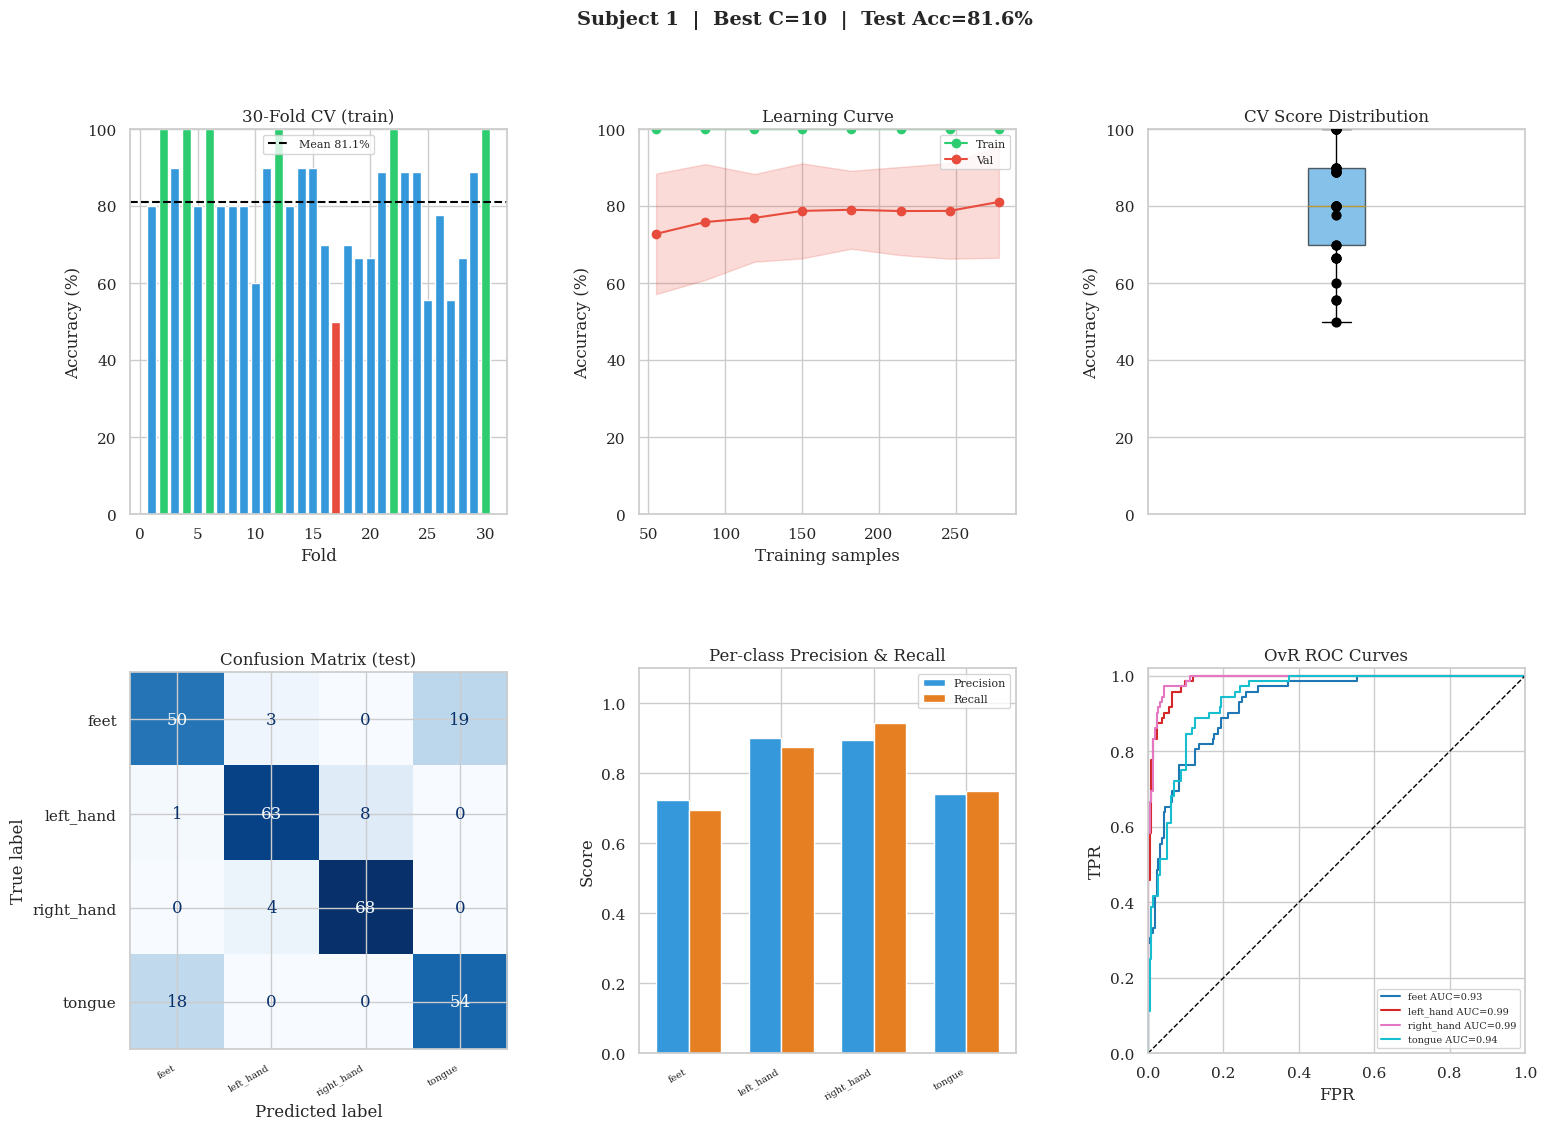

Subjects:  11%|█         | 1/9 [00:52<07:02, 52.84s/it]

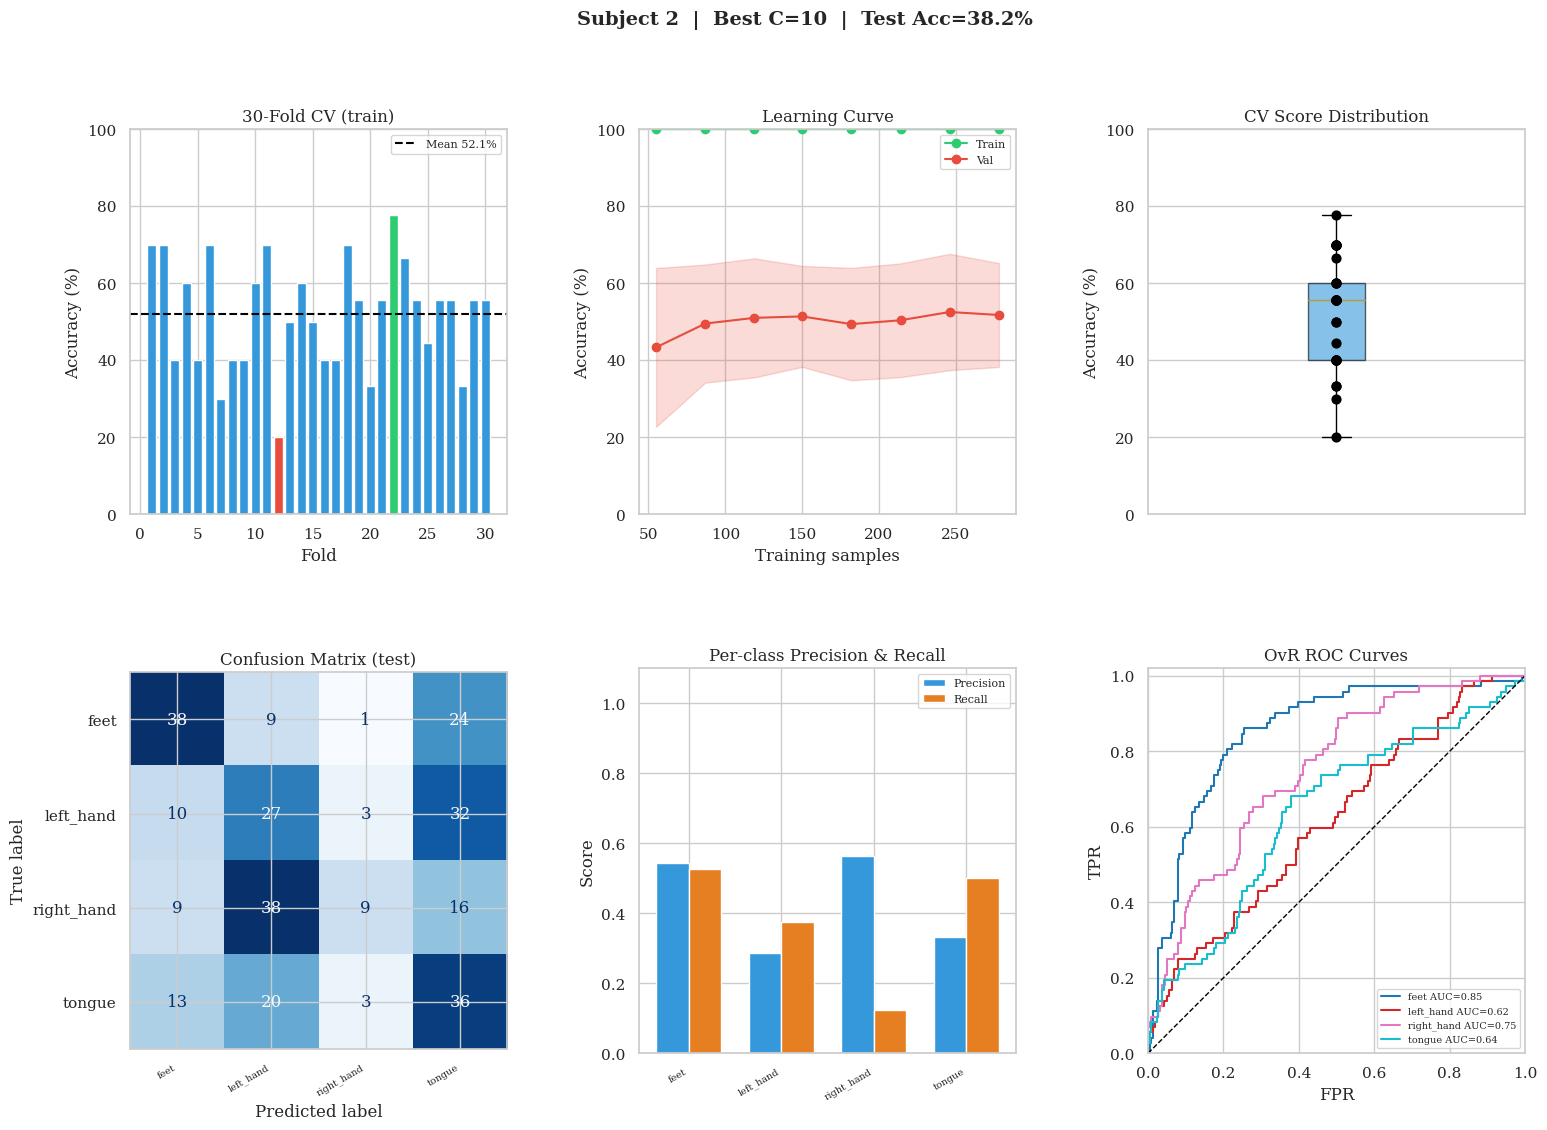

Subjects:  22%|██▏       | 2/9 [01:46<06:11, 53.14s/it]

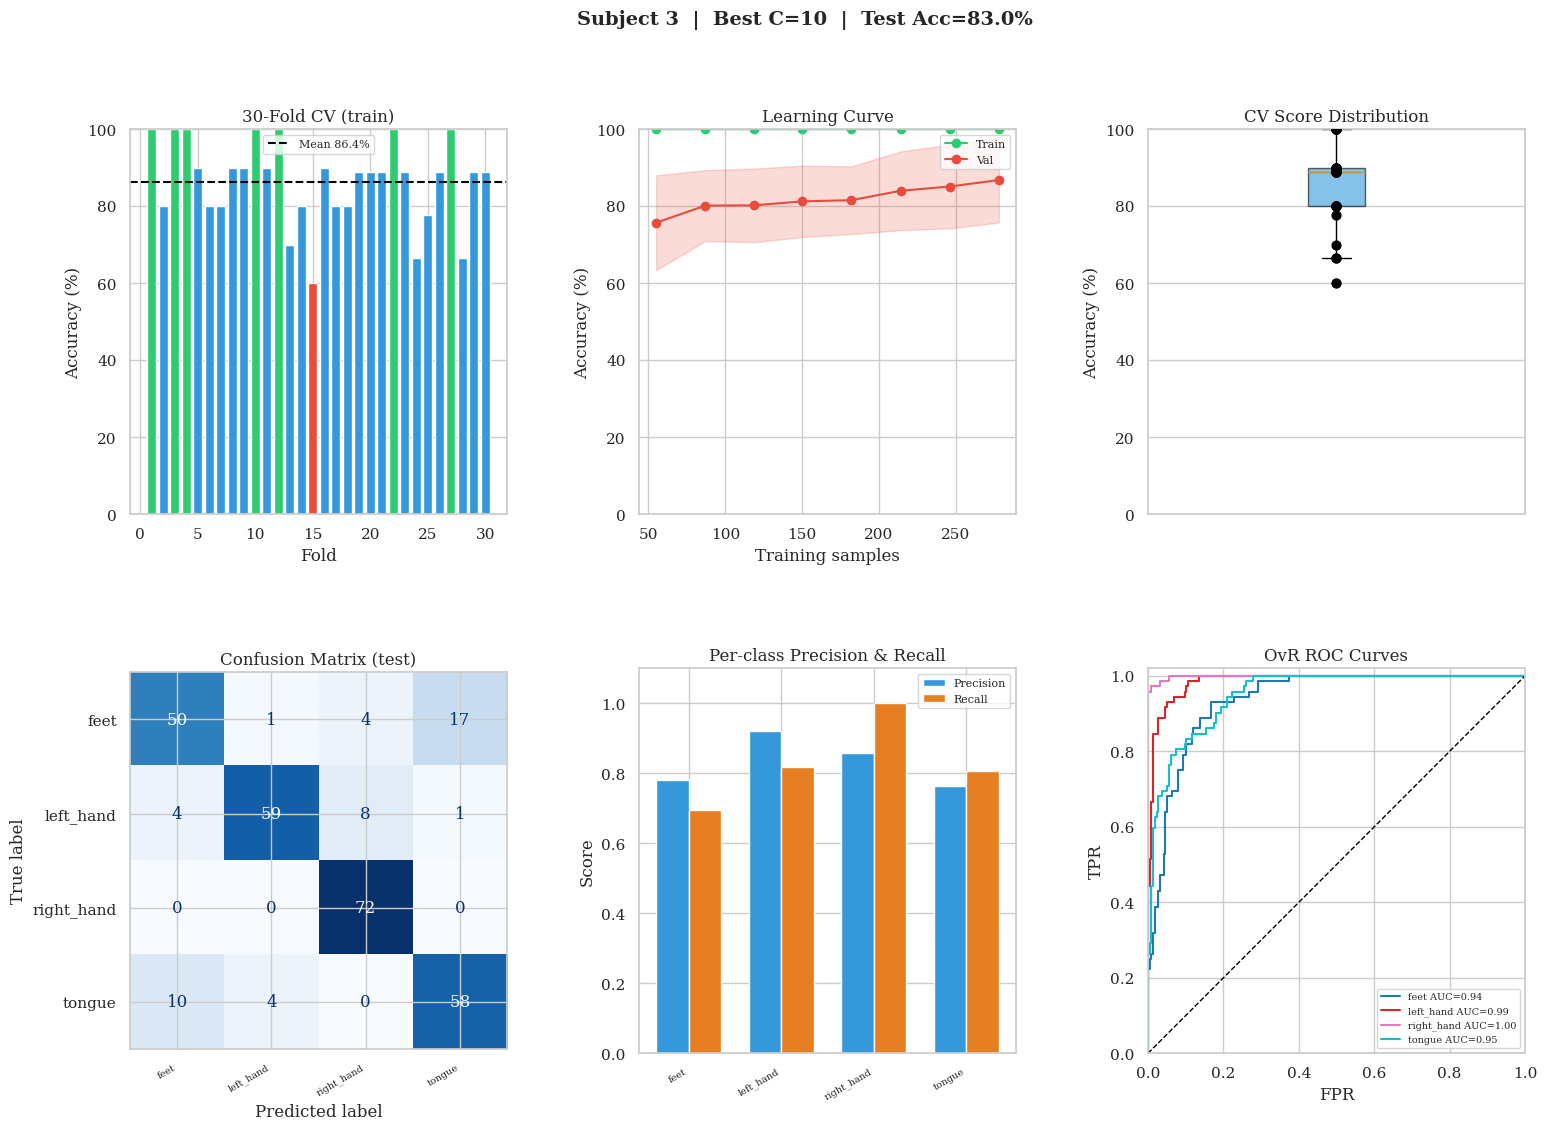

Subjects:  33%|███▎      | 3/9 [02:39<05:20, 53.40s/it]

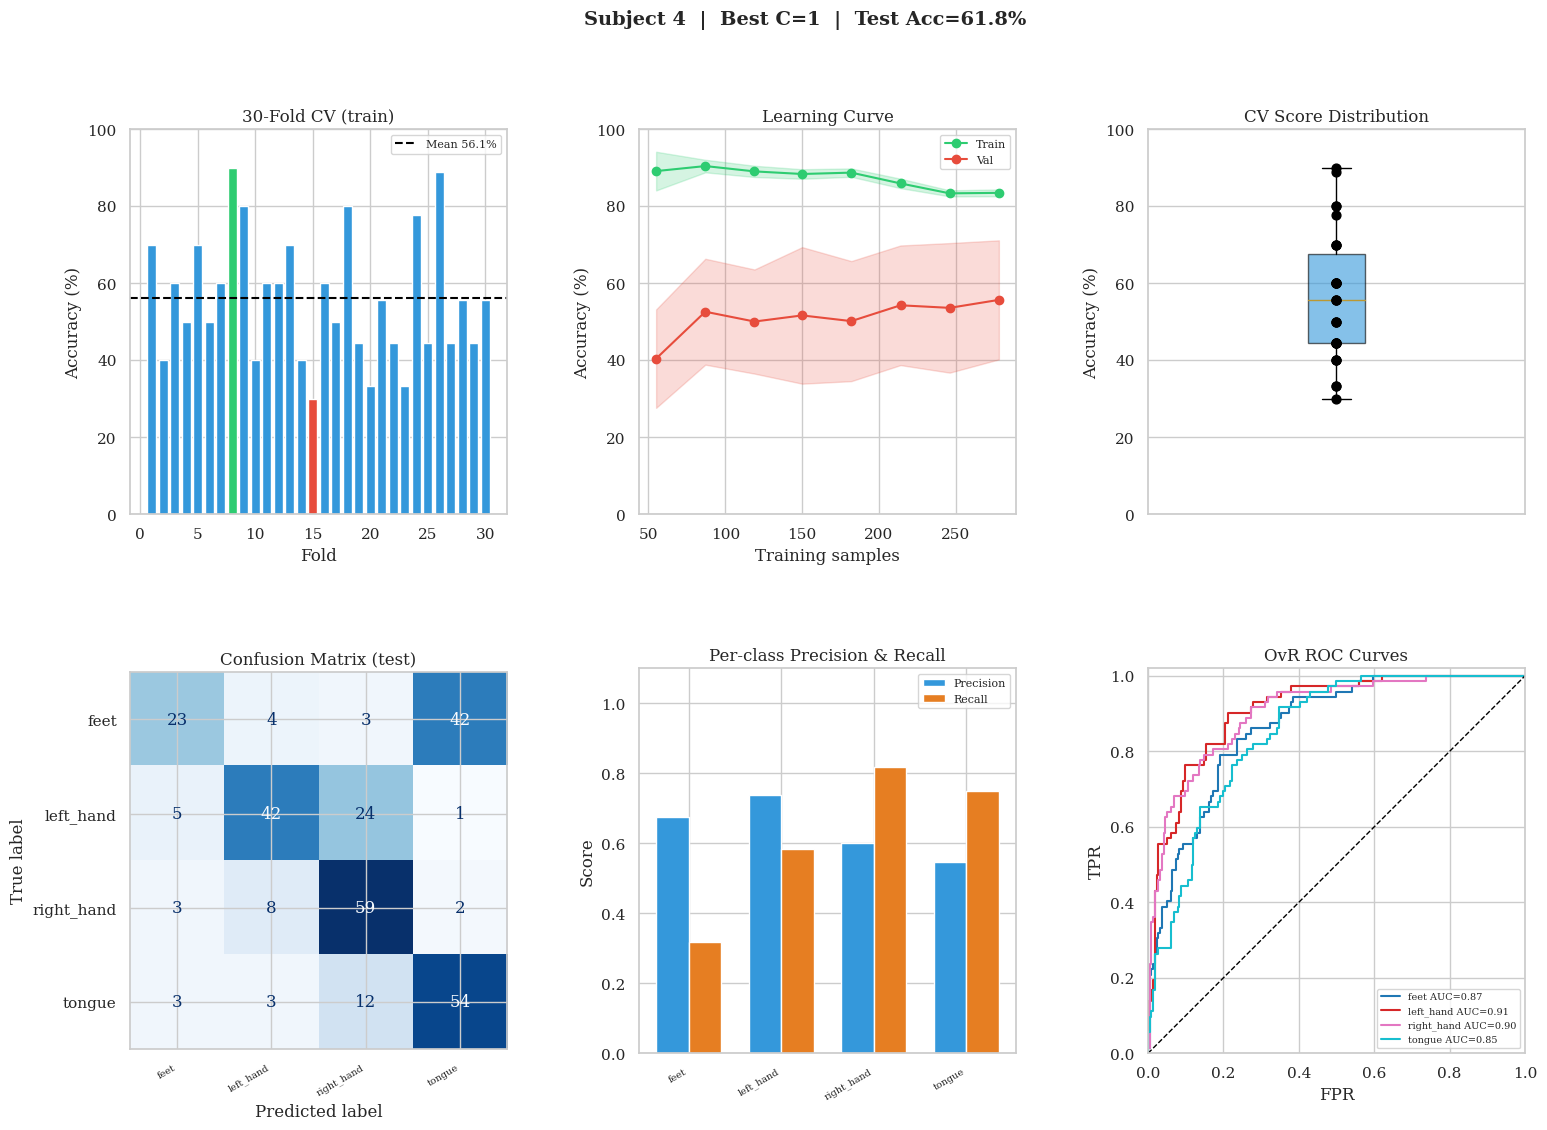

Subjects:  44%|████▍     | 4/9 [03:34<04:28, 53.69s/it]

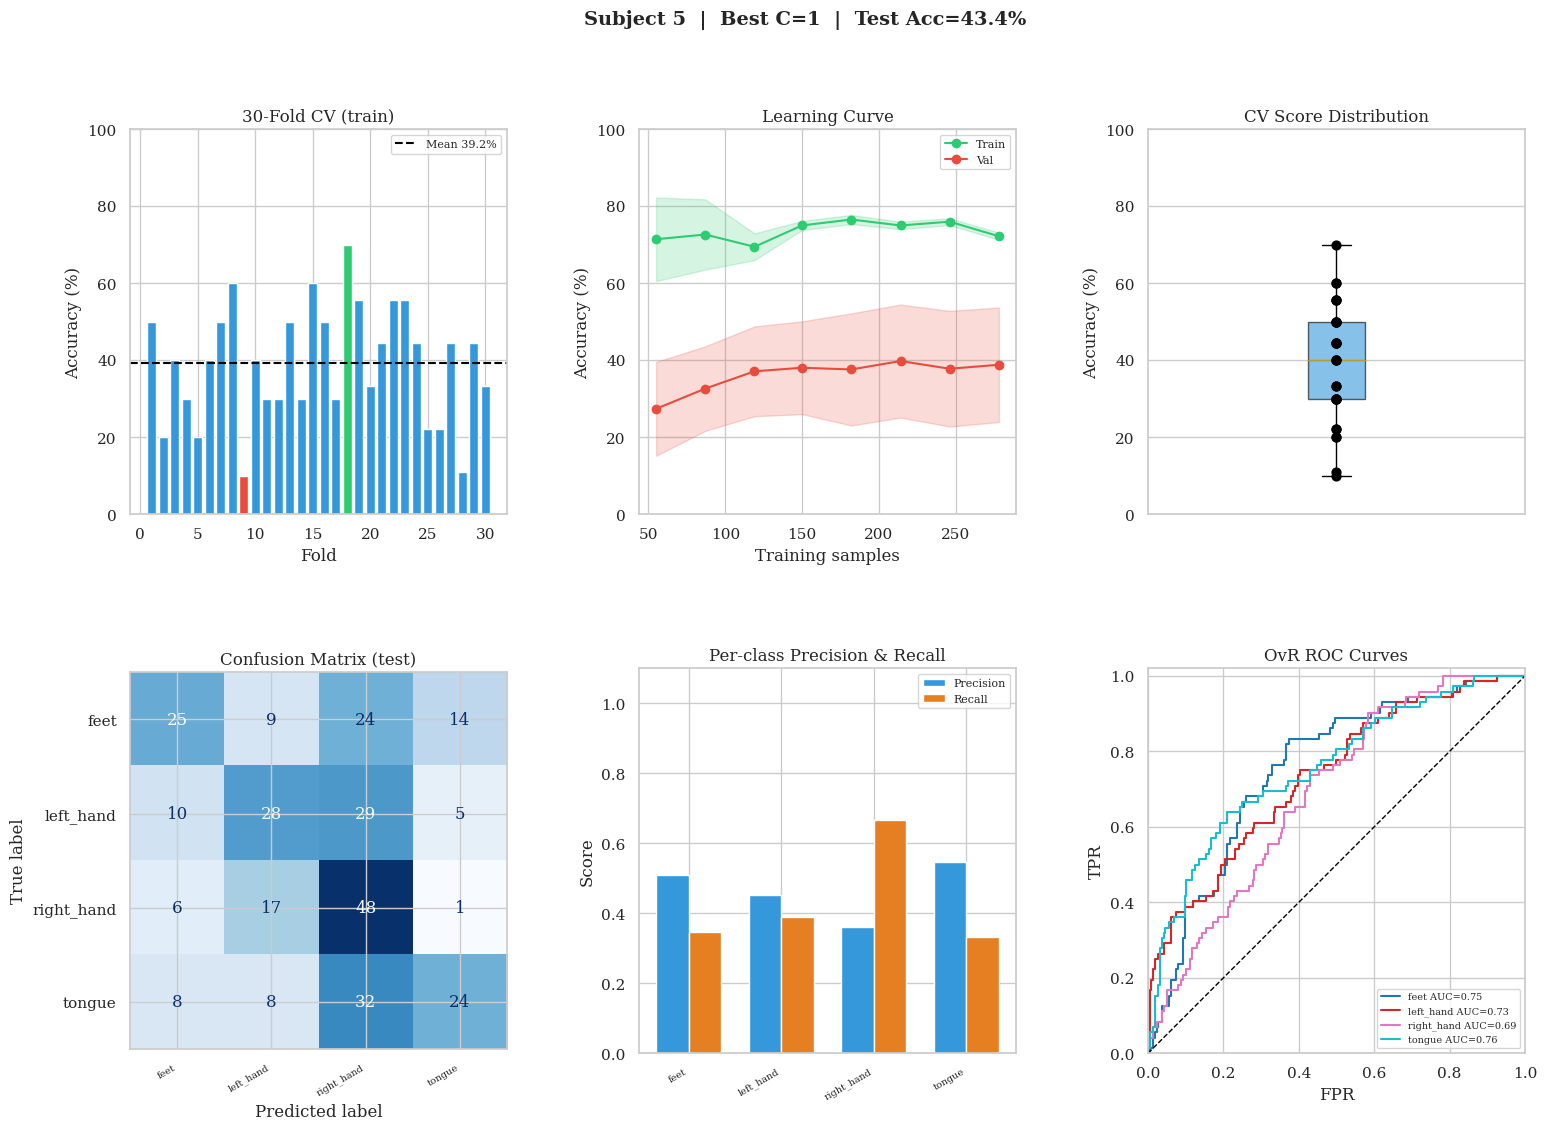

Subjects:  56%|█████▌    | 5/9 [04:29<03:37, 54.45s/it]

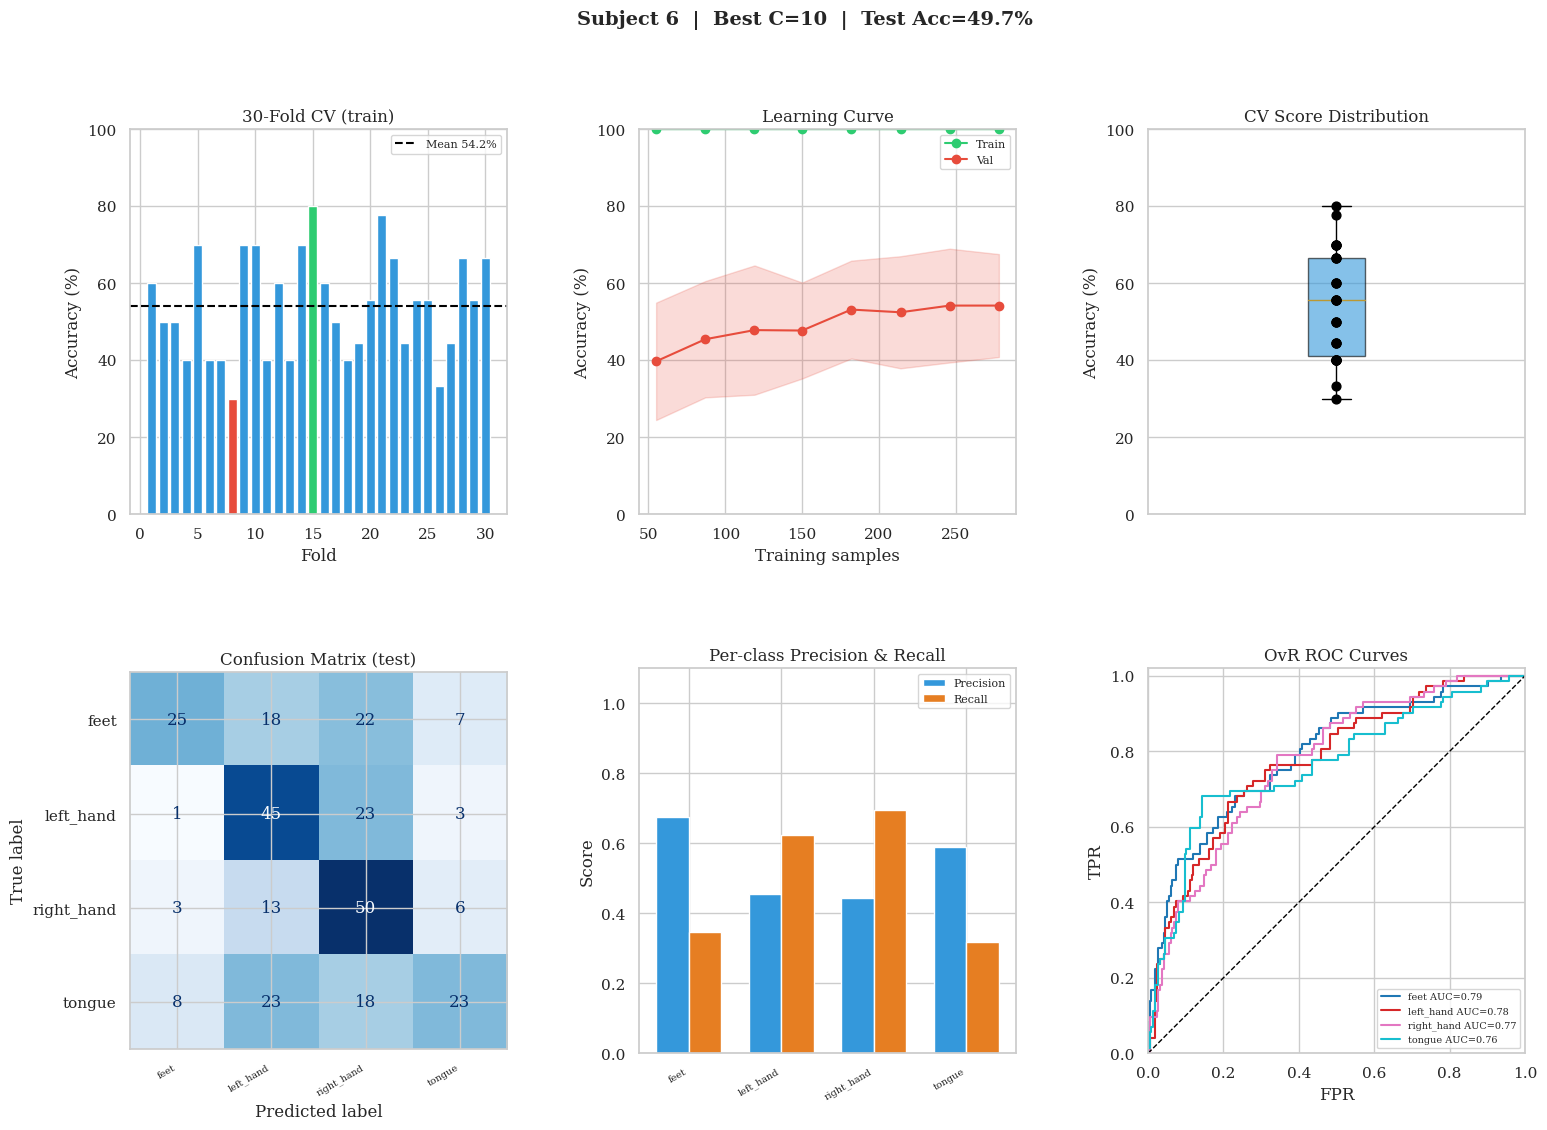

Subjects:  67%|██████▋   | 6/9 [05:24<02:43, 54.43s/it]

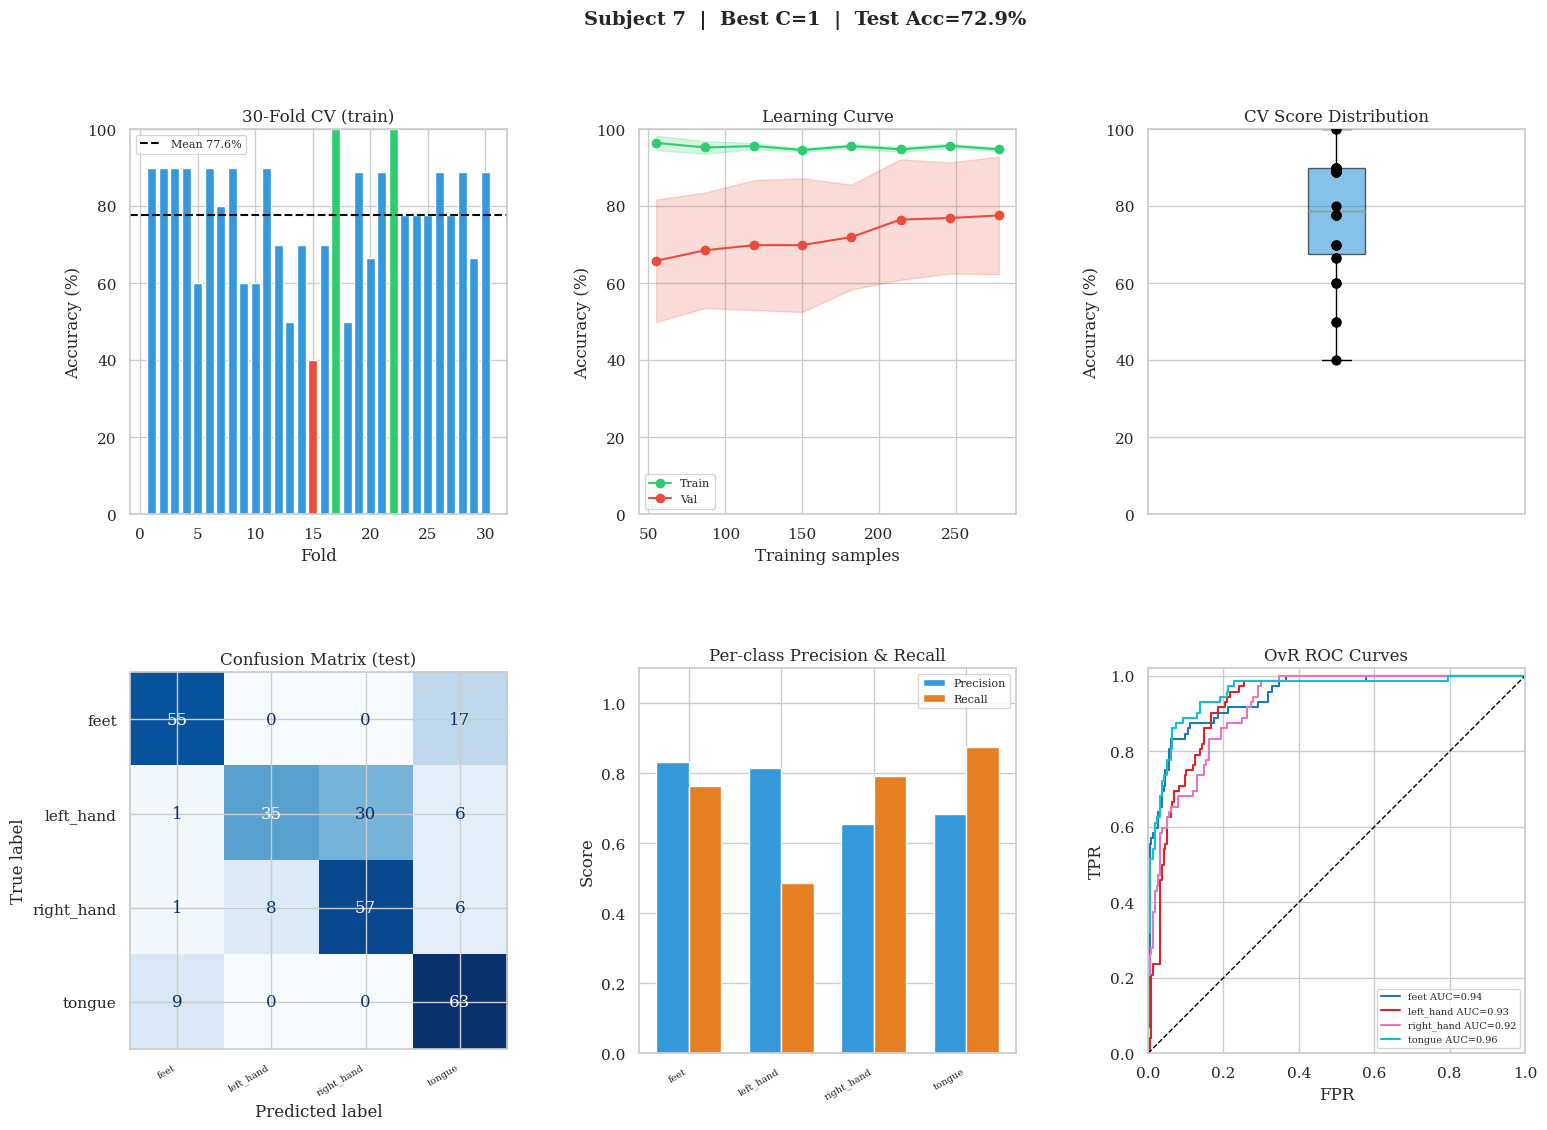

Subjects:  78%|███████▊  | 7/9 [06:18<01:48, 54.46s/it]

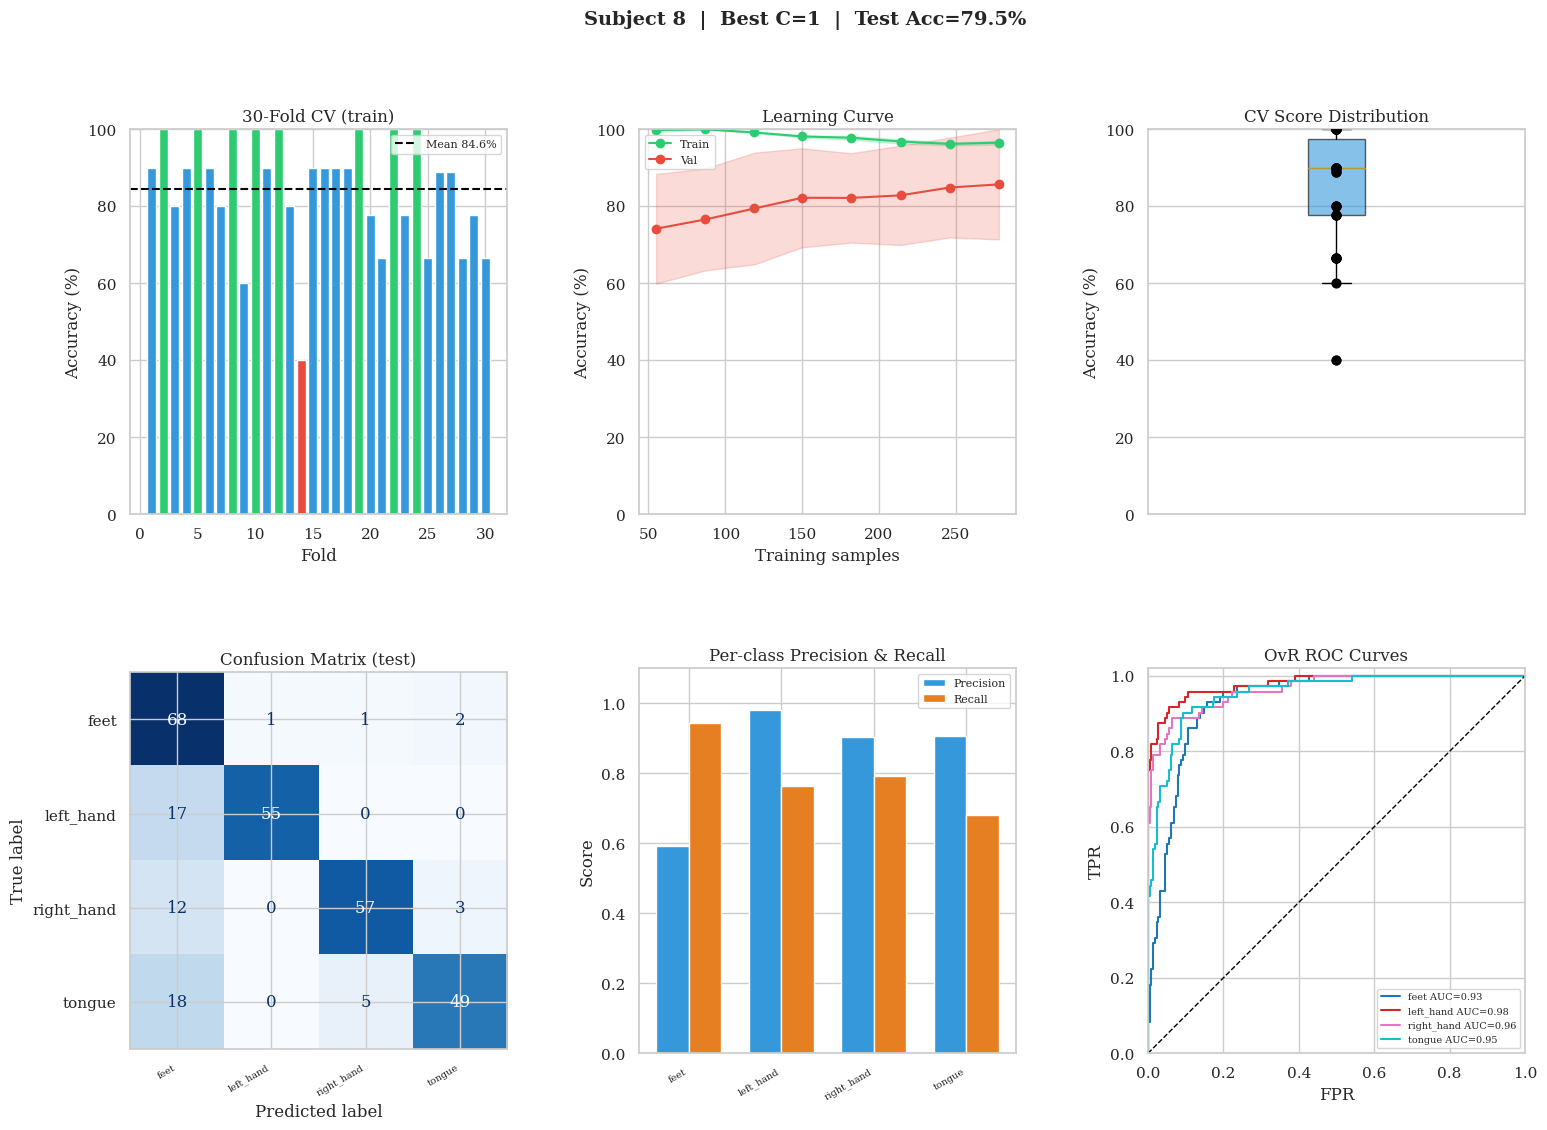

Subjects:  89%|████████▉ | 8/9 [07:12<00:54, 54.27s/it]

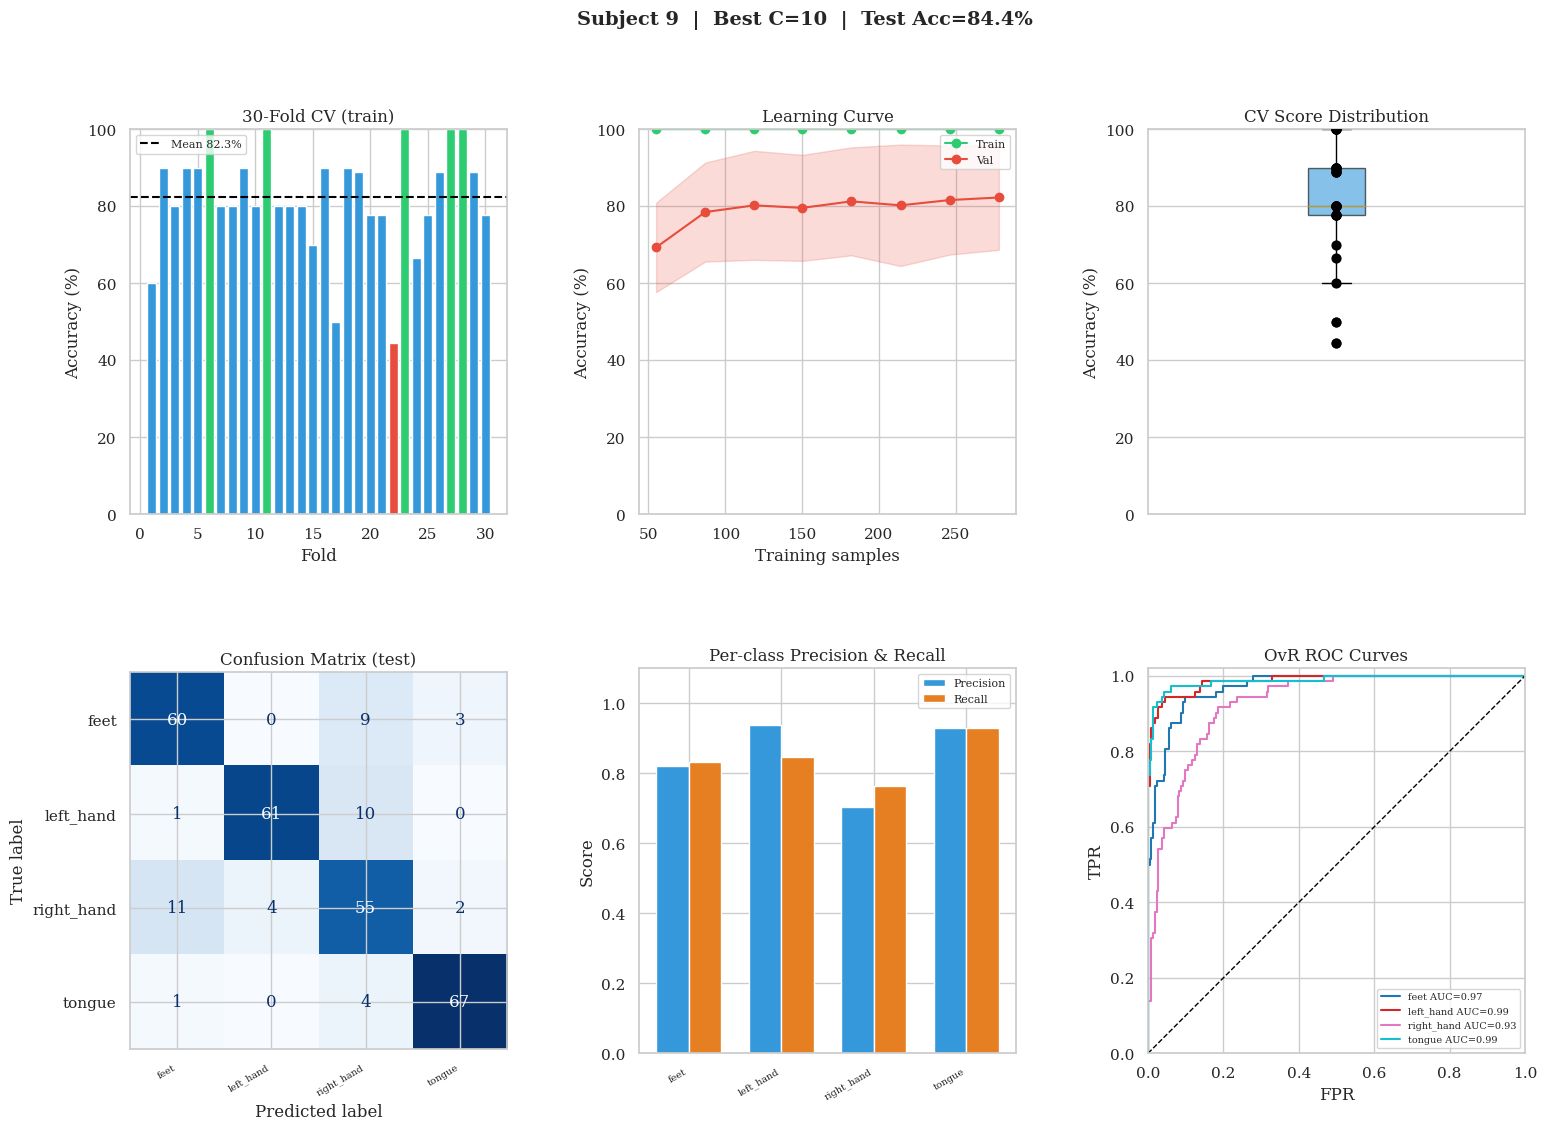

Subjects: 100%|██████████| 9/9 [08:07<00:00, 54.15s/it]


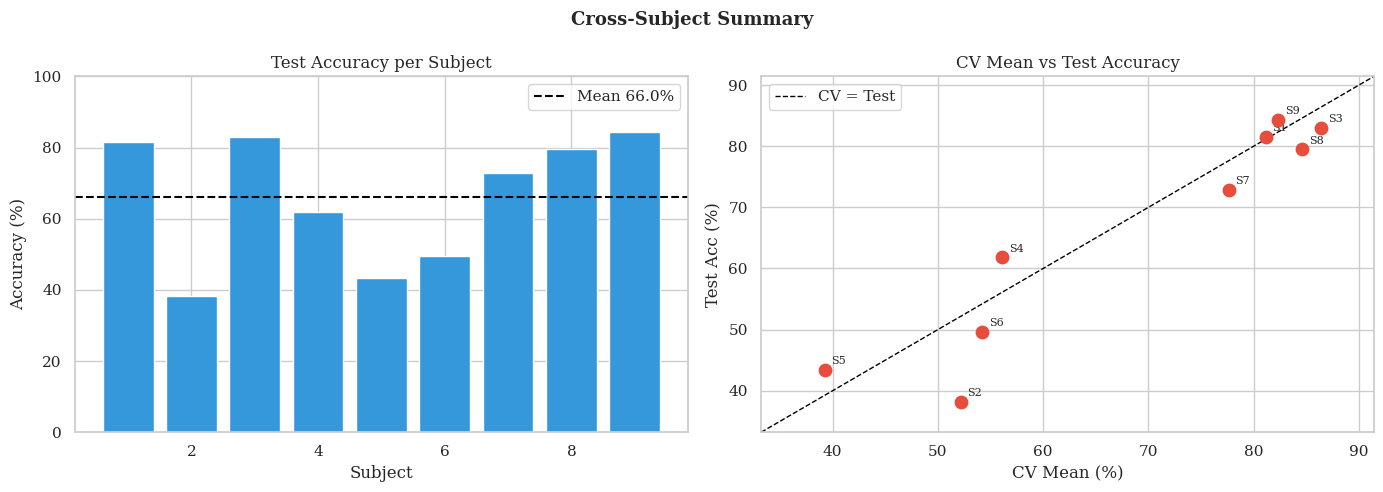


 Sub   Best C   CV Mean   CV Std   Test Acc
─────────────────────────────────────────────
   1       10     81.1%    14.5%      81.6%
   2       10     52.1%    14.0%      38.2%
   3       10     86.4%    10.8%      83.0%
   4        1     56.1%    16.1%      61.8%
   5        1     39.2%    14.9%      43.4%
   6       10     54.2%    13.4%      49.7%
   7        1     77.6%    15.3%      72.9%
   8        1     84.6%    14.4%      79.5%
   9       10     82.3%    13.6%      84.4%
─────────────────────────────────────────────
Mean              68.2%               66.0%


In [15]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (confusion_matrix, classification_report, 
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
SUBJECTS   = list(range(1, 10))
N_SPLITS   = 30
PARAM_GRID = {'svc__C': [0.01, 0.1, 1, 10, 100]}
CLASSES    = ['left_hand', 'right_hand', 'feet', 'tongue']

dataset  = BNCI2014001()
paradigm = ButterworthMotorImagery(fmin=8.0, fmax=30.0, tmin=0.5, tmax=2.5)

def make_pipeline(c=1.0):
    return Pipeline([
        ('scaler', MicrovoltScaler()),
        ('cov',    Covariances(estimator='oas')),
        ('kernel', SteinKernelTransformer(beta=0.5, normalized=True)),
        ('svc',    SVC(kernel='precomputed', C=c, probability=True)),
    ])

# ── Per-subject diagnostics ───────────────────────────────────────────────────
all_results = []

for subject in tqdm(SUBJECTS, desc='Subjects'):

    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])
    train_idx = metadata['session'] == '0train'
    test_idx  = metadata['session'] == '1test'
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    # 1. Grid-search best C on training fold
    base_pipe = make_pipeline()
    grid = GridSearchCV(base_pipe, PARAM_GRID,
                        cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=42),
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_c = grid.best_params_['svc__C']

    # 2. Final pipeline with best C — refit on ALL training data
    pipe = make_pipeline(best_c)
    pipe.fit(X_train, y_train)

    # 3. Test-set evaluation
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    test_acc = (y_pred == y_test).mean()

    # 4. K-fold CV scores on training set (learning stability)
    cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=42)
    cv_scores = cross_val_score(make_pipeline(best_c), X_train, y_train,
                                cv=cv, scoring='accuracy')

    # 5. Learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        make_pipeline(best_c), X_train, y_train,
        cv=cv, train_sizes=np.linspace(0.2, 1.0, 8),
        scoring='accuracy', n_jobs=-1)

    all_results.append(dict(
        subject=subject, best_c=best_c, test_acc=test_acc,
        cv_scores=cv_scores, y_test=y_test, y_pred=y_pred, y_prob=y_prob,
        train_sizes=train_sizes, train_scores=train_scores, val_scores=val_scores,
    ))

    # ── Per-subject figure ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'Subject {subject}  |  Best C={best_c}  |  Test Acc={test_acc*100:.1f}%',
                 fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # (a) K-fold bar chart
    ax0 = fig.add_subplot(gs[0, 0])
    colors = ['#e74c3c' if s == cv_scores.min() else
              '#2ecc71' if s == cv_scores.max() else '#3498db'
              for s in cv_scores]
    ax0.bar(range(1, N_SPLITS+1), cv_scores * 100, color=colors, edgecolor='white')
    ax0.axhline(cv_scores.mean()*100, color='k', ls='--', lw=1.5,
                label=f'Mean {cv_scores.mean()*100:.1f}%')
    ax0.set(title=f'{N_SPLITS}-Fold CV (train)', xlabel='Fold', ylabel='Accuracy (%)')
    ax0.set_ylim(0, 100); ax0.legend(fontsize=8)

    # (b) Learning curve
    ax1 = fig.add_subplot(gs[0, 1])
    tr_mean = train_scores.mean(1)*100;  tr_std = train_scores.std(1)*100
    va_mean = val_scores.mean(1)*100;    va_std = val_scores.std(1)*100
    ax1.plot(train_sizes, tr_mean, 'o-', color='#2ecc71', label='Train')
    ax1.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2, color='#2ecc71')
    ax1.plot(train_sizes, va_mean, 'o-', color='#e74c3c', label='Val')
    ax1.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.2, color='#e74c3c')
    ax1.set(title='Learning Curve', xlabel='Training samples', ylabel='Accuracy (%)')
    ax1.set_ylim(0, 100); ax1.legend(fontsize=8)

    # (c) CV score distribution (box/strip)
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.boxplot(cv_scores*100, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax2.scatter([1]*N_SPLITS, cv_scores*100, color='k', zorder=5, s=40)
    ax2.set(title='CV Score Distribution', ylabel='Accuracy (%)', xticks=[])
    ax2.set_ylim(0, 100)

    # (d) Confusion matrix
    ax3 = fig.add_subplot(gs[1, 0])
    present = np.unique(np.concatenate([y_test, y_pred]))
    cm = confusion_matrix(y_test, y_pred, labels=present)
    disp = ConfusionMatrixDisplay(cm, display_labels=present)
    disp.plot(ax=ax3, colorbar=False, cmap='Blues')
    ax3.set_title('Confusion Matrix (test)')
    plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=7)

    # (e) Per-class precision / recall bar
    ax4 = fig.add_subplot(gs[1, 1])
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cls_labels = [k for k in report if k not in ('accuracy','macro avg','weighted avg')]
    prec = [report[c]['precision'] for c in cls_labels]
    rec  = [report[c]['recall']    for c in cls_labels]
    x = np.arange(len(cls_labels)); w = 0.35
    ax4.bar(x-w/2, prec, w, label='Precision', color='#3498db')
    ax4.bar(x+w/2, rec,  w, label='Recall',    color='#e67e22')
    ax4.set(title='Per-class Precision & Recall', ylabel='Score',
            xticks=x, xticklabels=cls_labels)
    plt.setp(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    ax4.set_ylim(0, 1.1); ax4.legend(fontsize=8)

    # (f) One-vs-Rest ROC curves
    ax5 = fig.add_subplot(gs[1, 2])
    unique_classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=unique_classes)
    cmap  = plt.cm.get_cmap('tab10', len(unique_classes))
    for i, cls in enumerate(unique_classes):
        col_idx = list(pipe.classes_).index(cls) if hasattr(pipe, 'classes_') else i
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, col_idx])
        ax5.plot(fpr, tpr, color=cmap(i), lw=1.5,
                 label=f'{cls} AUC={auc(fpr,tpr):.2f}')
    ax5.plot([0,1],[0,1],'k--',lw=1); ax5.set_xlim(0,1); ax5.set_ylim(0,1.02)
    ax5.set(title='OvR ROC Curves', xlabel='FPR', ylabel='TPR')
    ax5.legend(fontsize=7, loc='lower right')

    plt.savefig(f'subject_{subject}_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Summary across subjects ───────────────────────────────────────────────────
accs   = [r['test_acc']          for r in all_results]
cv_means = [r['cv_scores'].mean() for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Subject Summary', fontsize=13, fontweight='bold')

# Bar chart of test accuracies
axes[0].bar(SUBJECTS, [a*100 for a in accs], color='#3498db', edgecolor='white')
axes[0].axhline(np.mean(accs)*100, color='k', ls='--',
                label=f'Mean {np.mean(accs)*100:.1f}%')
axes[0].set(title='Test Accuracy per Subject', xlabel='Subject', ylabel='Accuracy (%)')
axes[0].set_ylim(0,100); axes[0].legend()

# CV mean vs test accuracy scatter
axes[1].scatter([c*100 for c in cv_means], [a*100 for a in accs],
                s=80, color='#e74c3c', zorder=5)
for i, s in enumerate(SUBJECTS):
    axes[1].annotate(f'S{s}', (cv_means[i]*100, accs[i]*100),
                     textcoords='offset points', xytext=(5,4), fontsize=8)
mn, mx = min(cv_means+accs)*100-5, max(cv_means+accs)*100+5
axes[1].plot([mn,mx],[mn,mx],'k--',lw=1,label='CV = Test')
axes[1].set(title='CV Mean vs Test Accuracy', xlabel='CV Mean (%)', ylabel='Test Acc (%)')
axes[1].set_xlim(mn,mx); axes[1].set_ylim(mn,mx); axes[1].legend()

plt.tight_layout()
plt.savefig('summary_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Sub':>4} {'Best C':>8} {'CV Mean':>9} {'CV Std':>8} {'Test Acc':>10}")
print("─"*45)
for r in all_results:
    print(f"{r['subject']:>4} {r['best_c']:>8} "
          f"{r['cv_scores'].mean()*100:>8.1f}% "
          f"{r['cv_scores'].std()*100:>7.1f}% "
          f"{r['test_acc']*100:>9.1f}%")
print("─"*45)
print(f"{'Mean':>4} {'':>8} {np.mean(cv_means)*100:>8.1f}% {'':>8} {np.mean(accs)*100:>9.1f}%")

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events
Subjects:   0%|          | 0/9 [00:00<?, ?it/s]

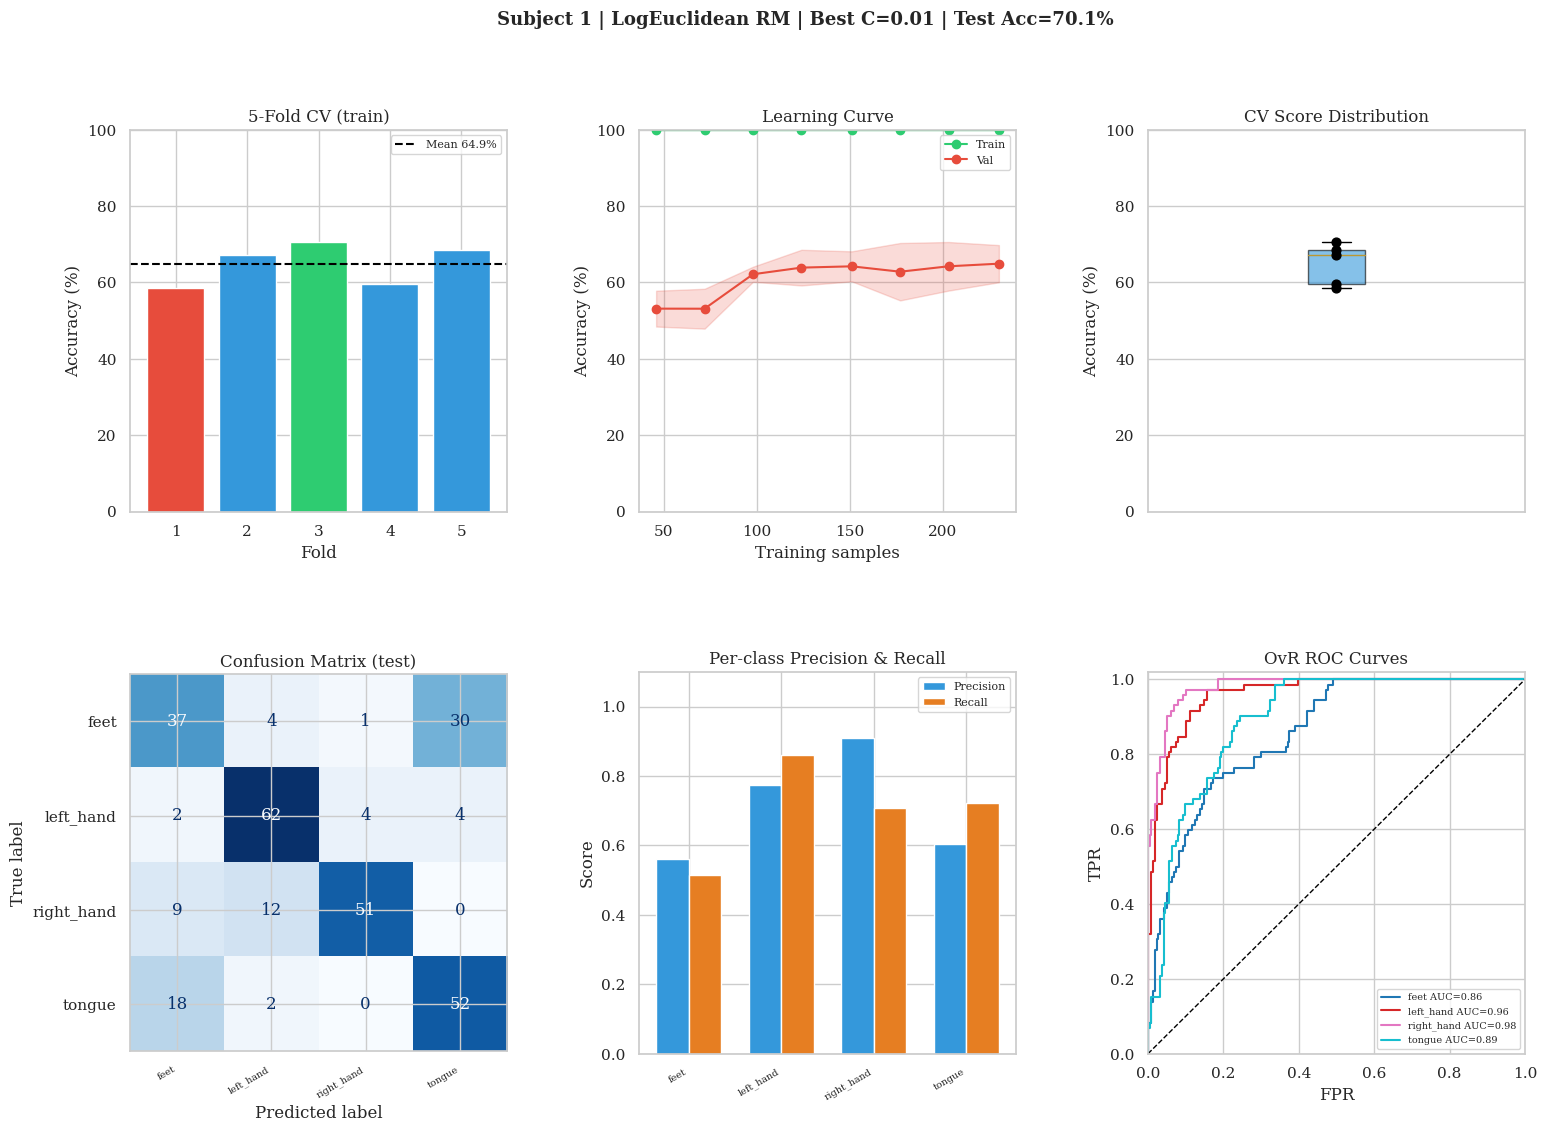

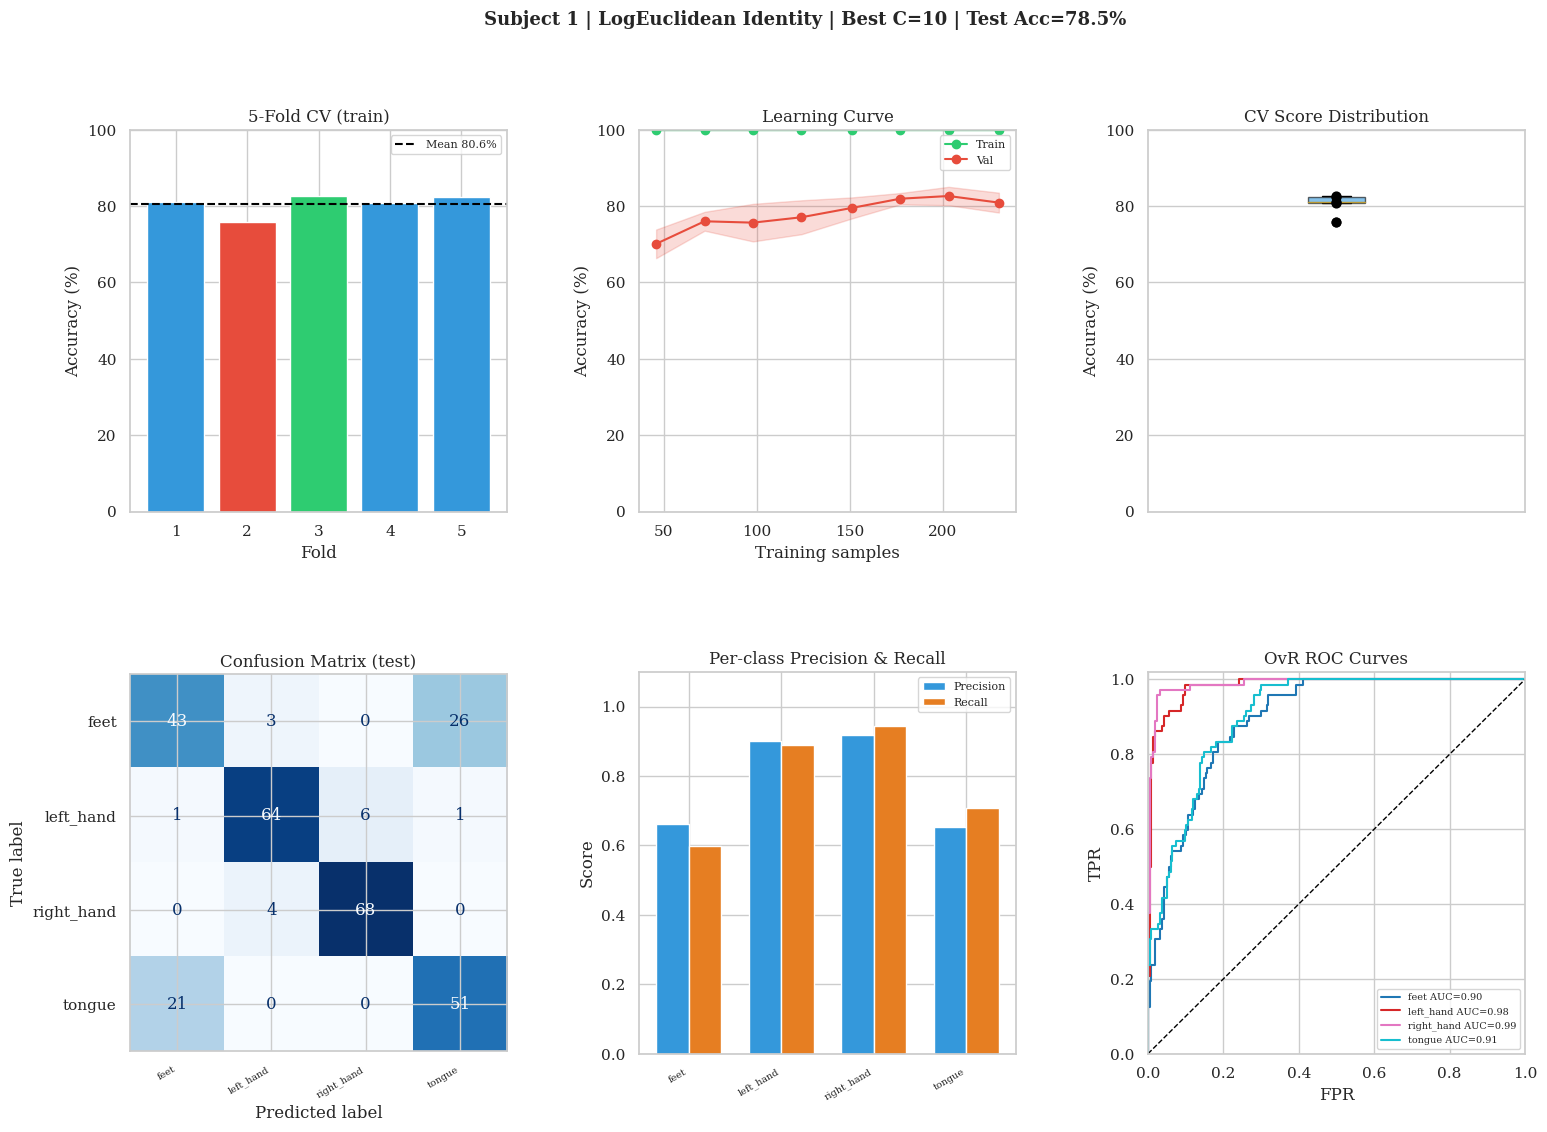

Subjects:  11%|█         | 1/9 [00:27<03:39, 27.41s/it]

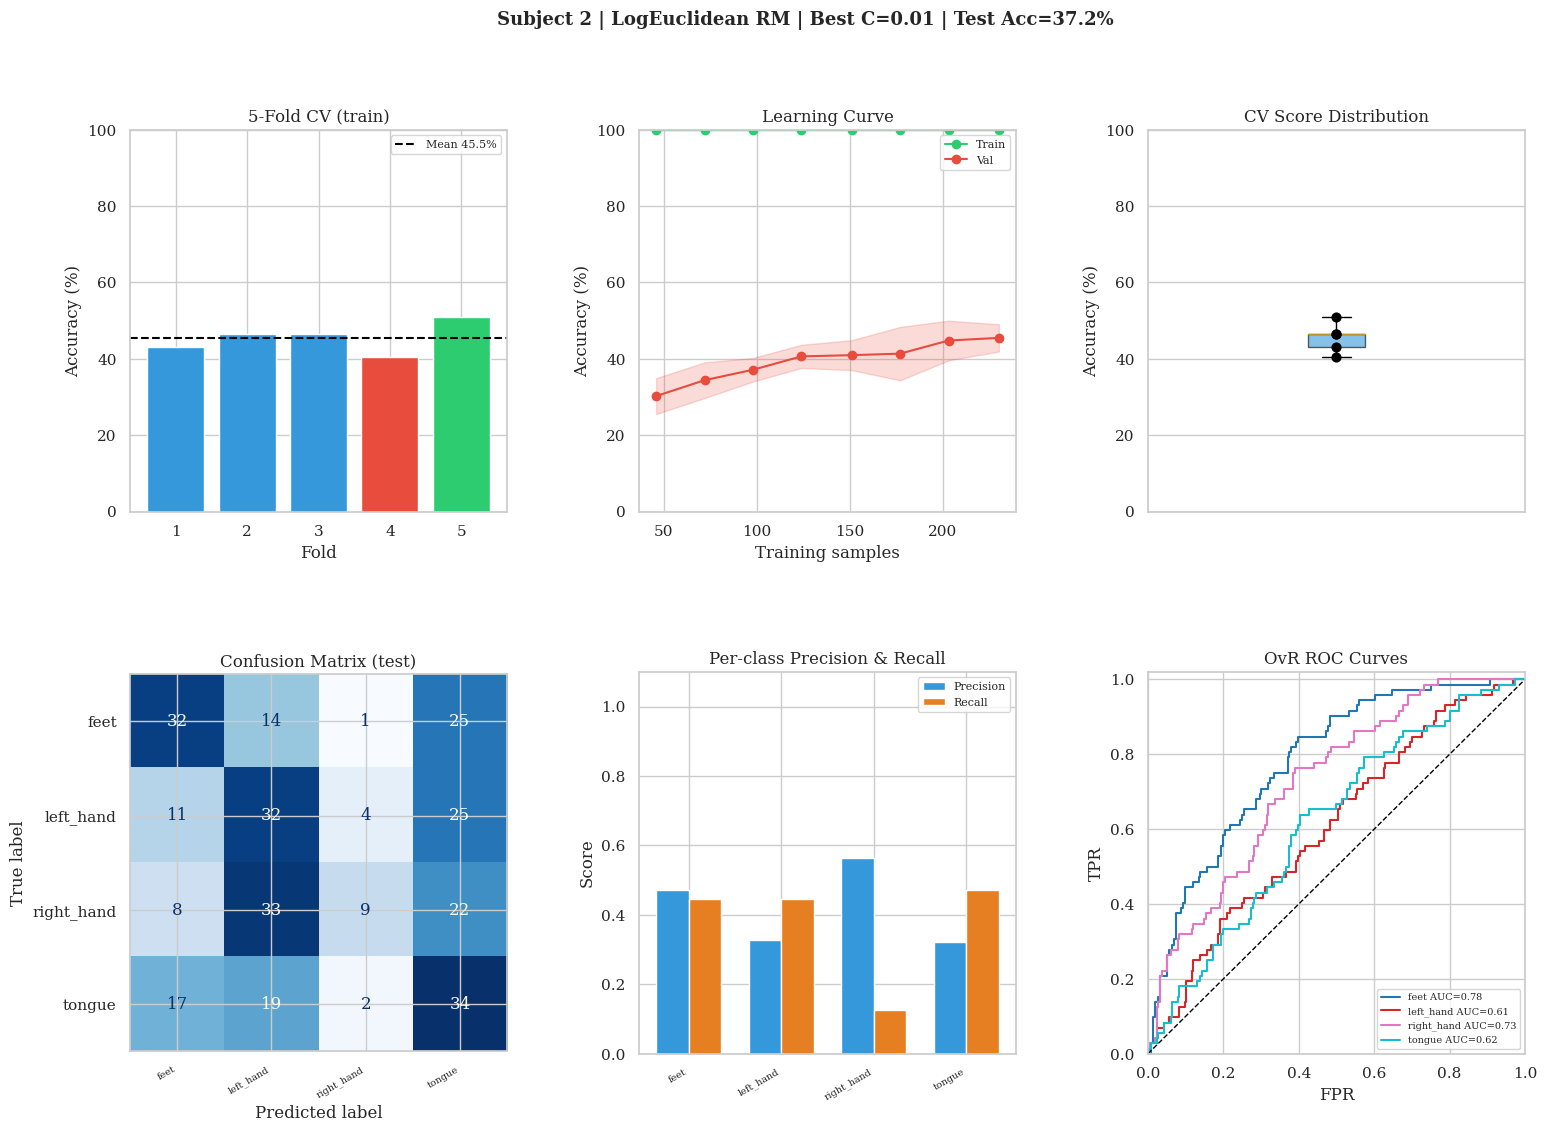

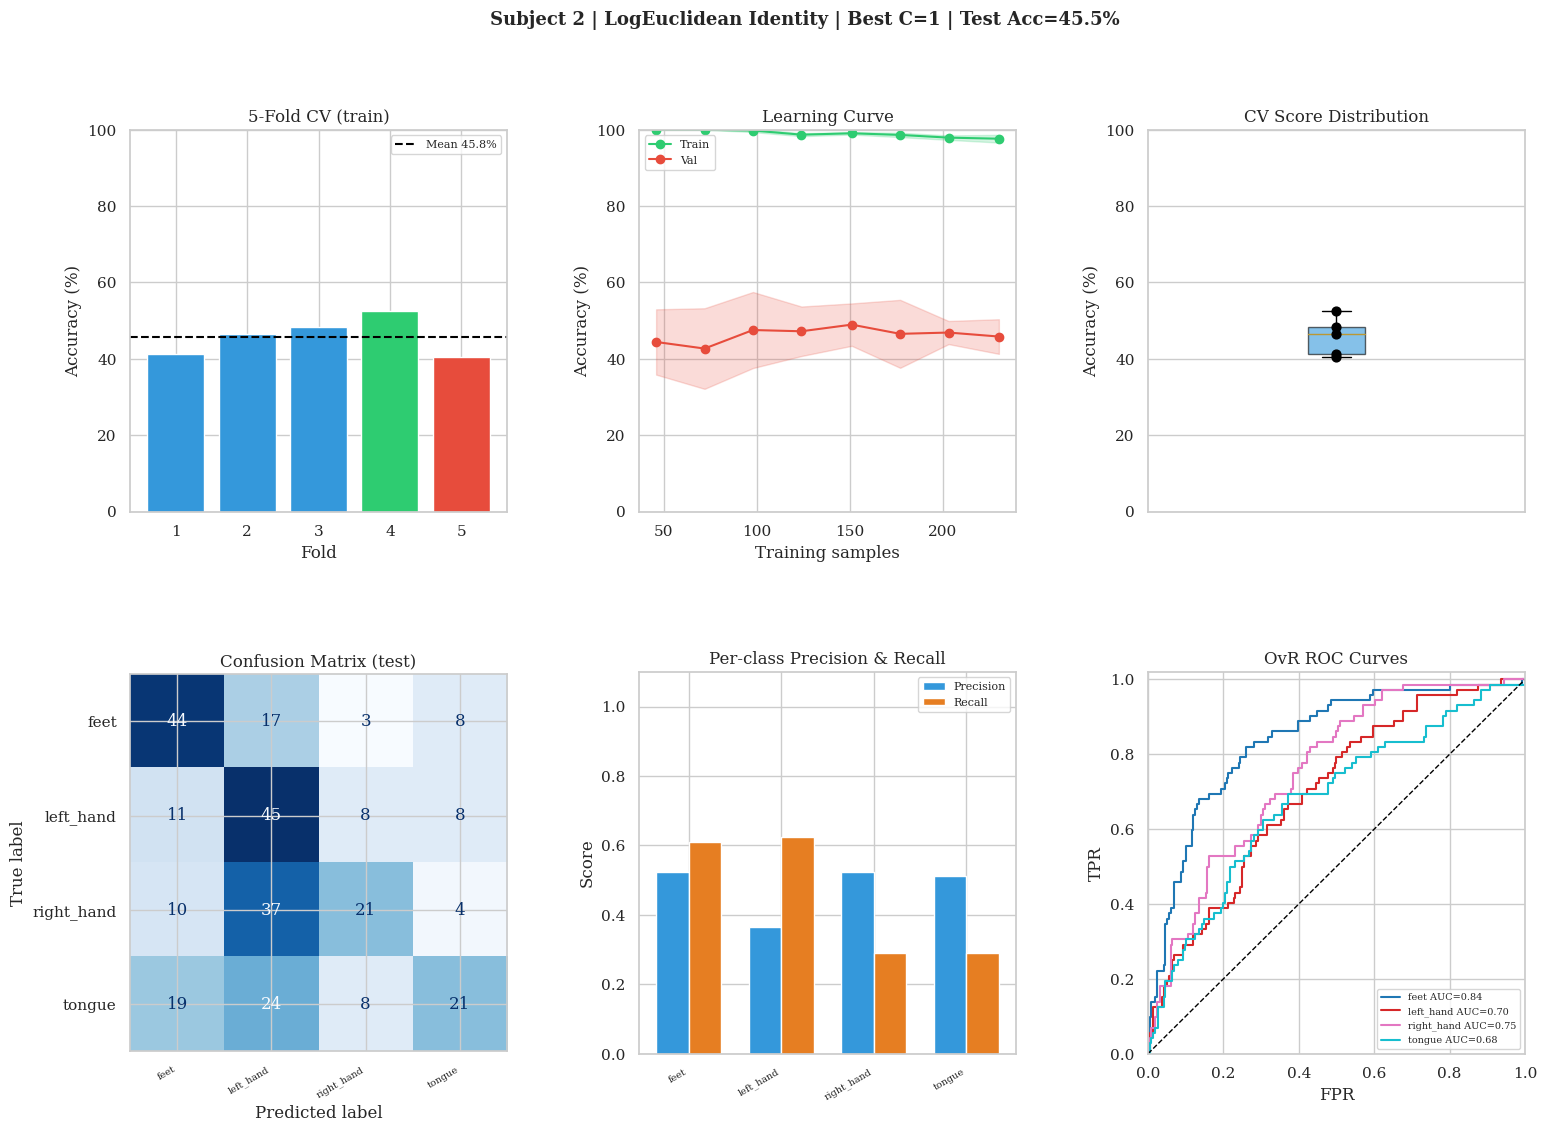

Subjects:  22%|██▏       | 2/9 [01:17<04:45, 40.81s/it]

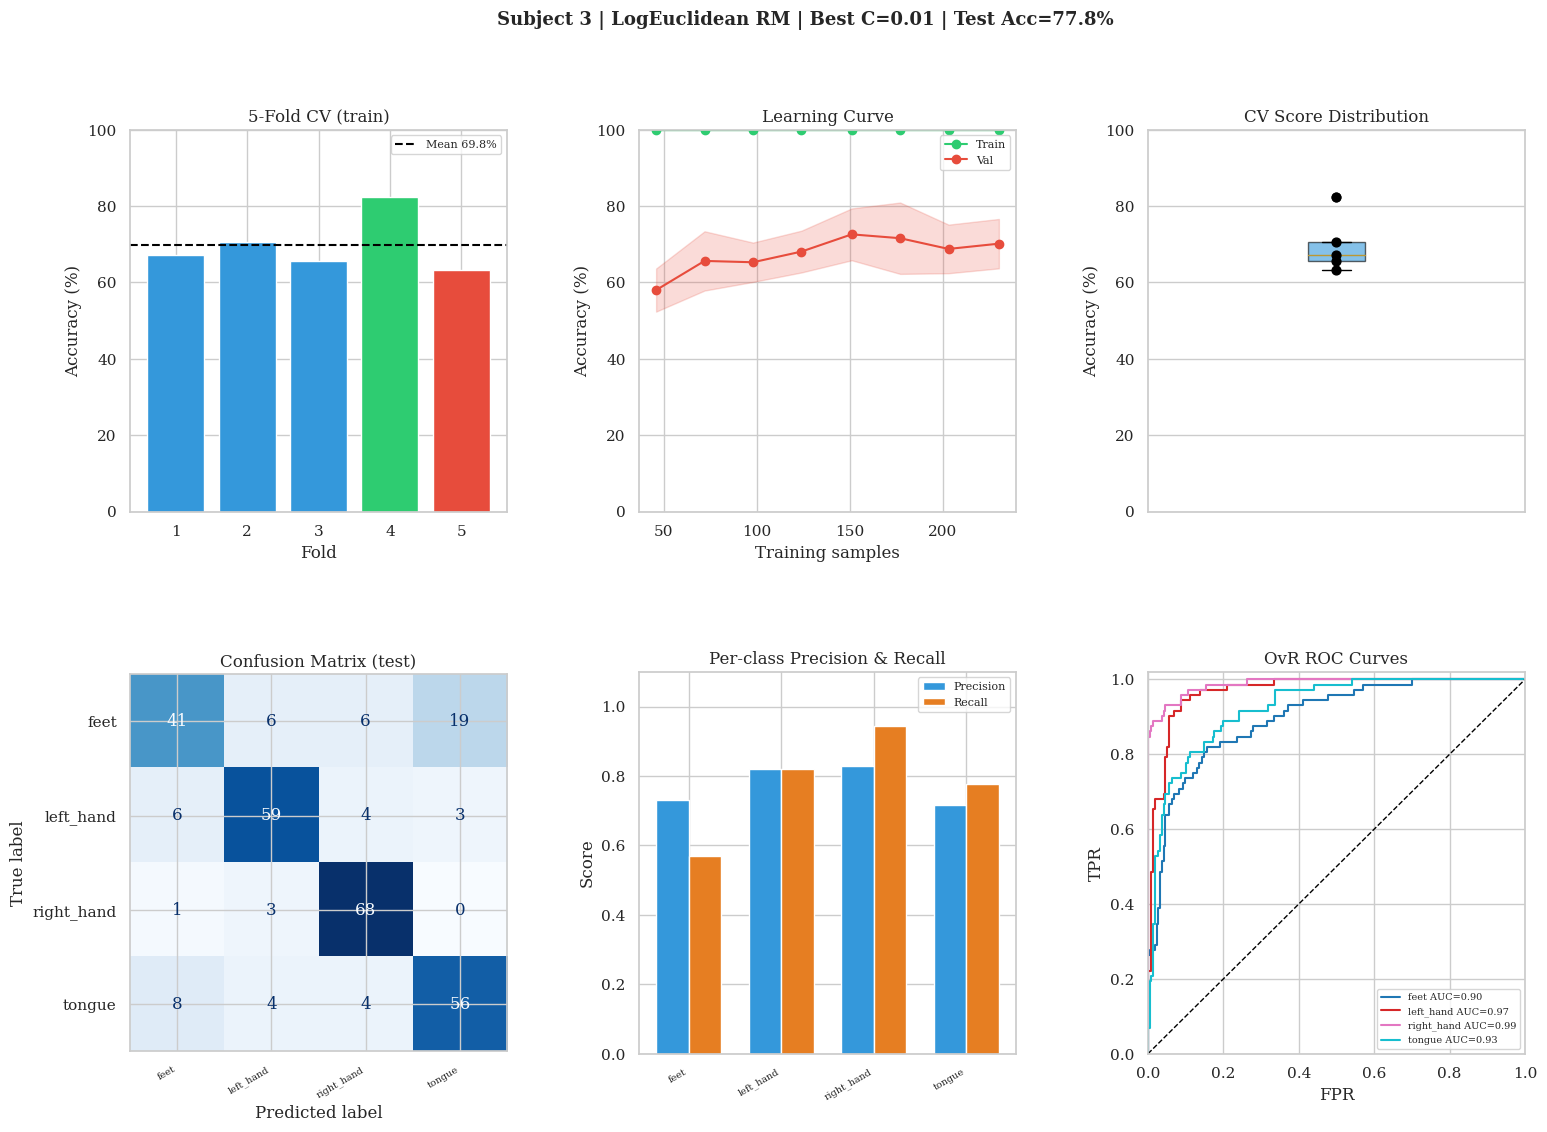

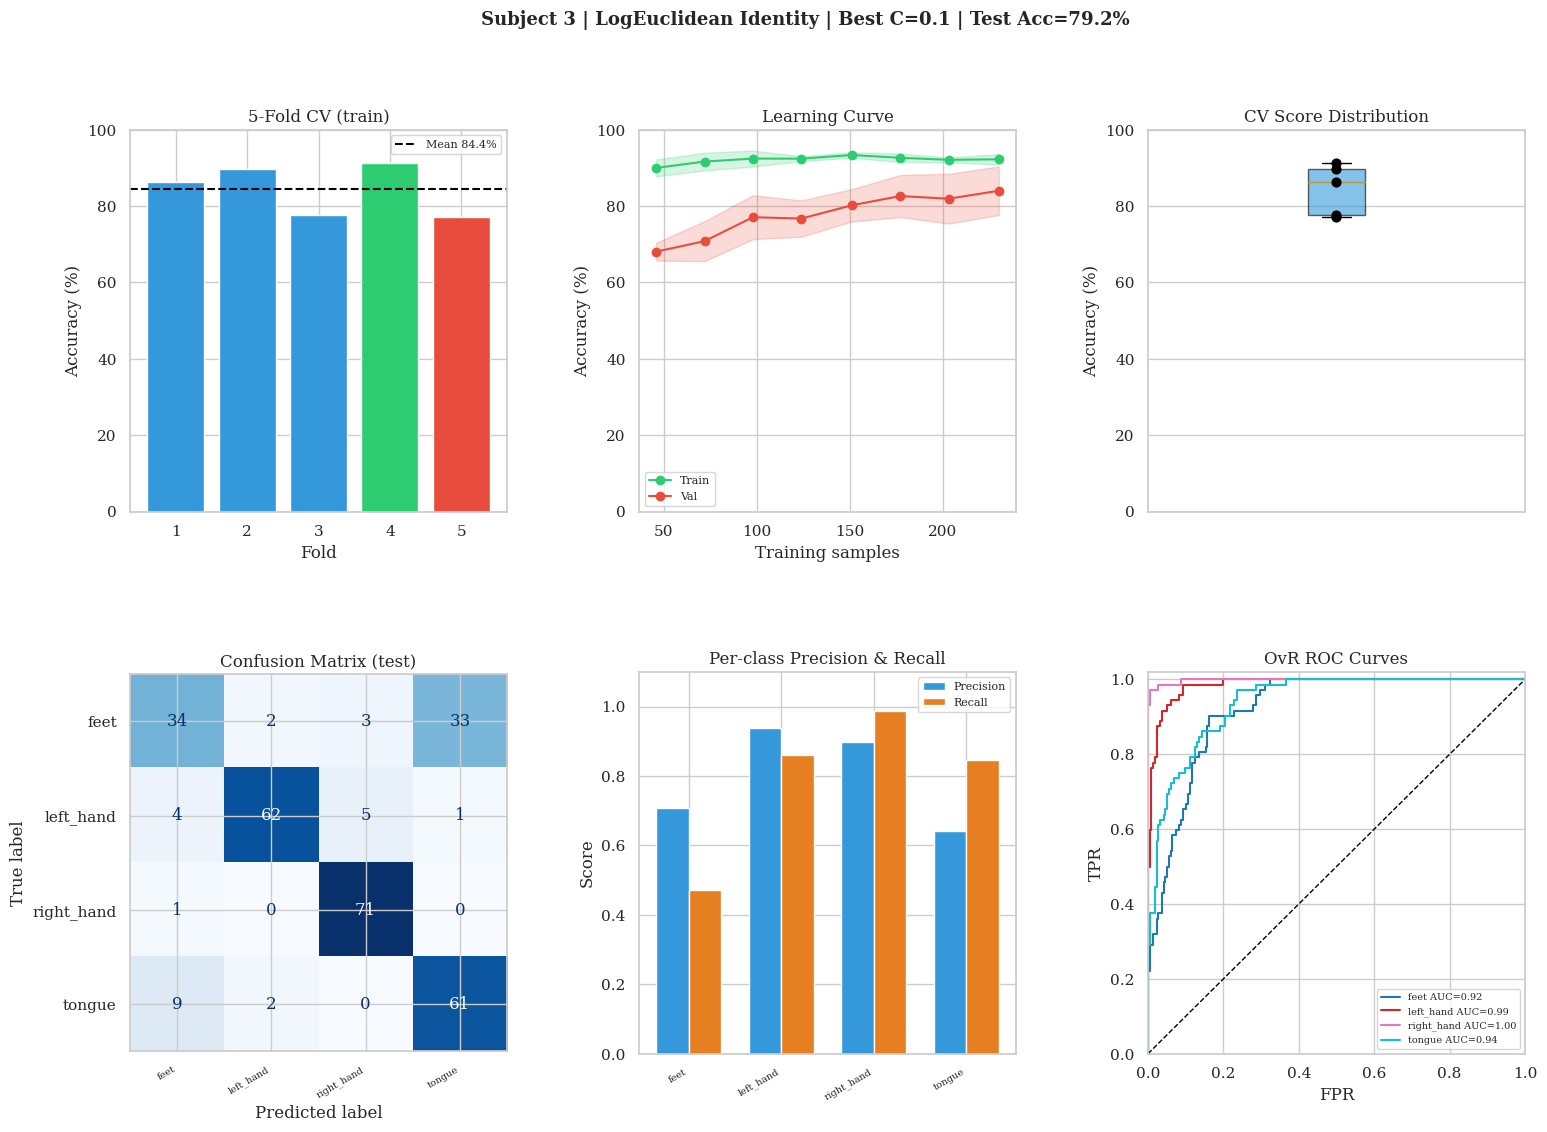

Subjects:  33%|███▎      | 3/9 [01:44<03:25, 34.32s/it]

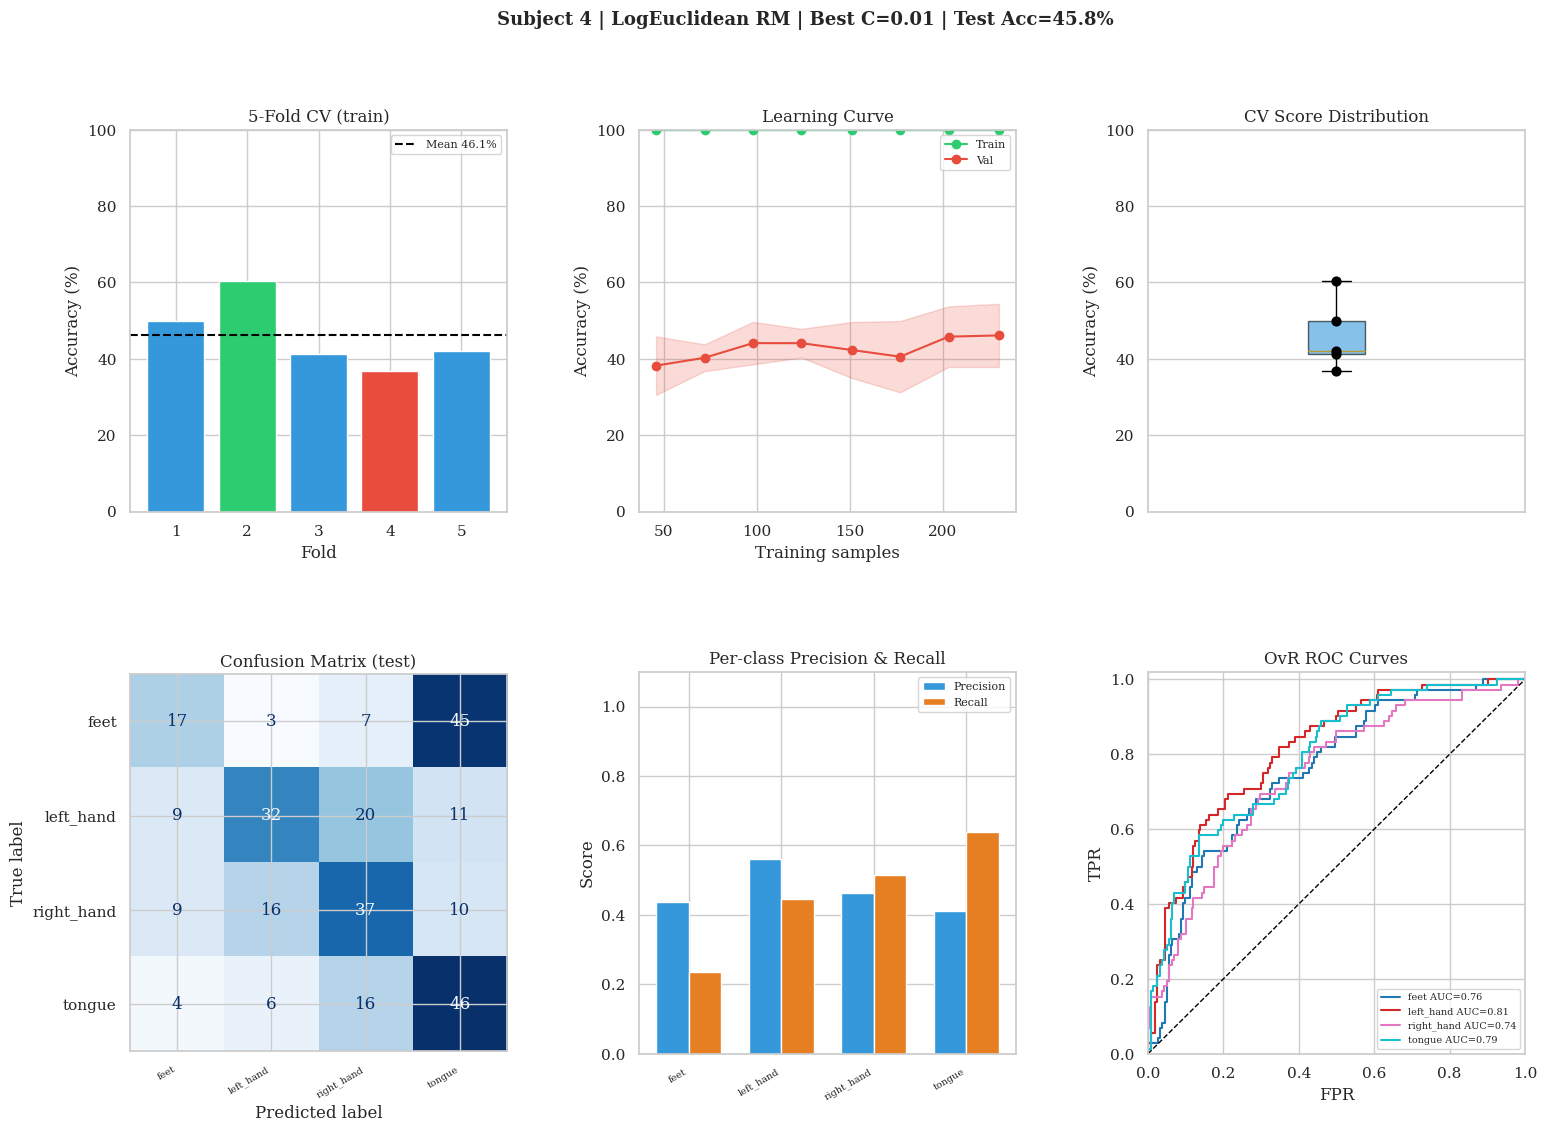

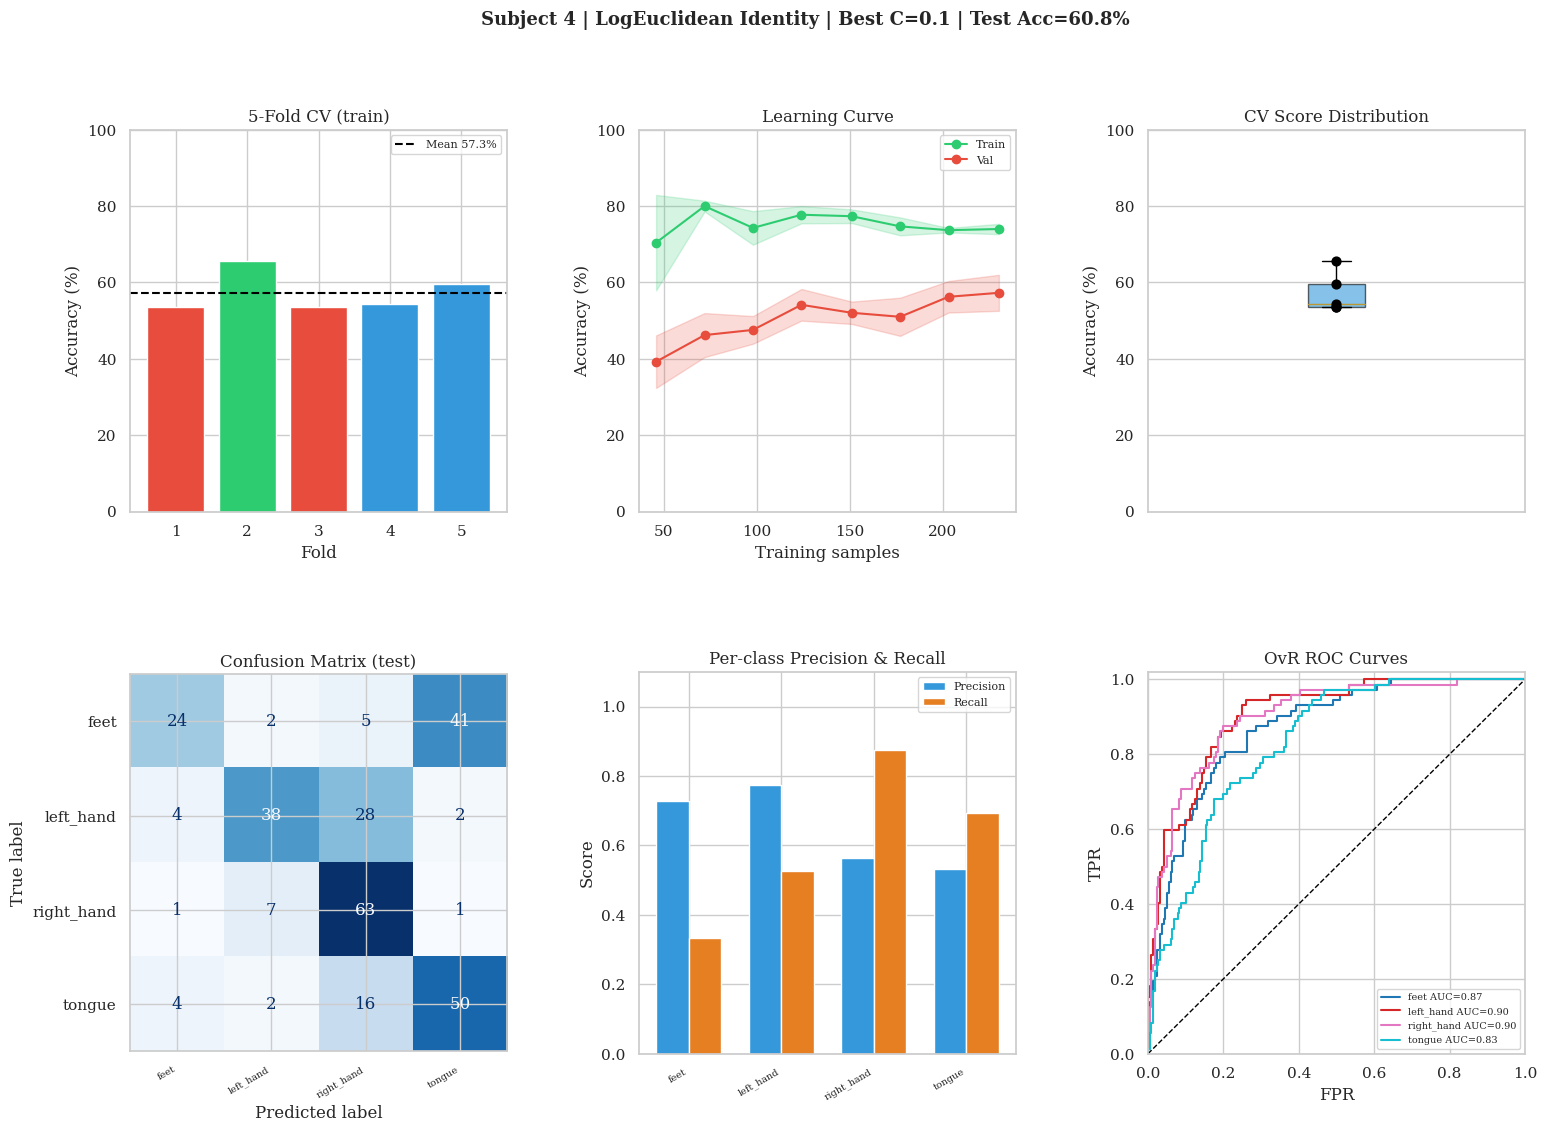

Subjects:  44%|████▍     | 4/9 [02:16<02:47, 33.49s/it]

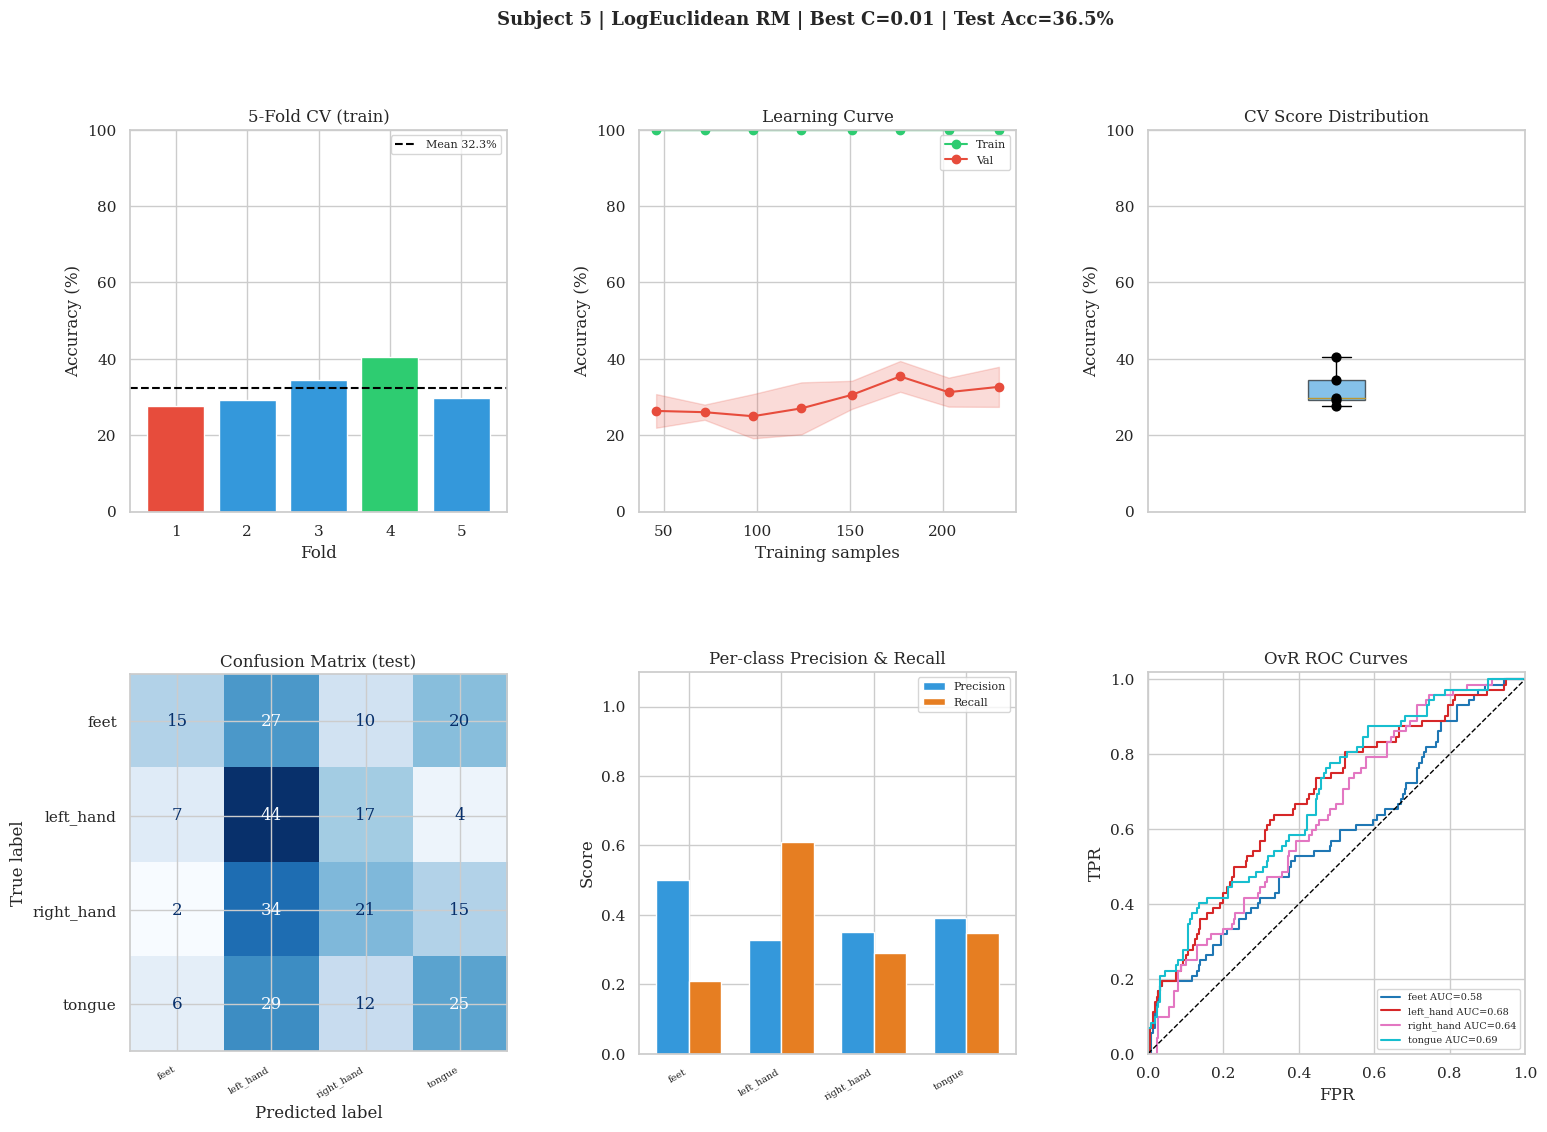

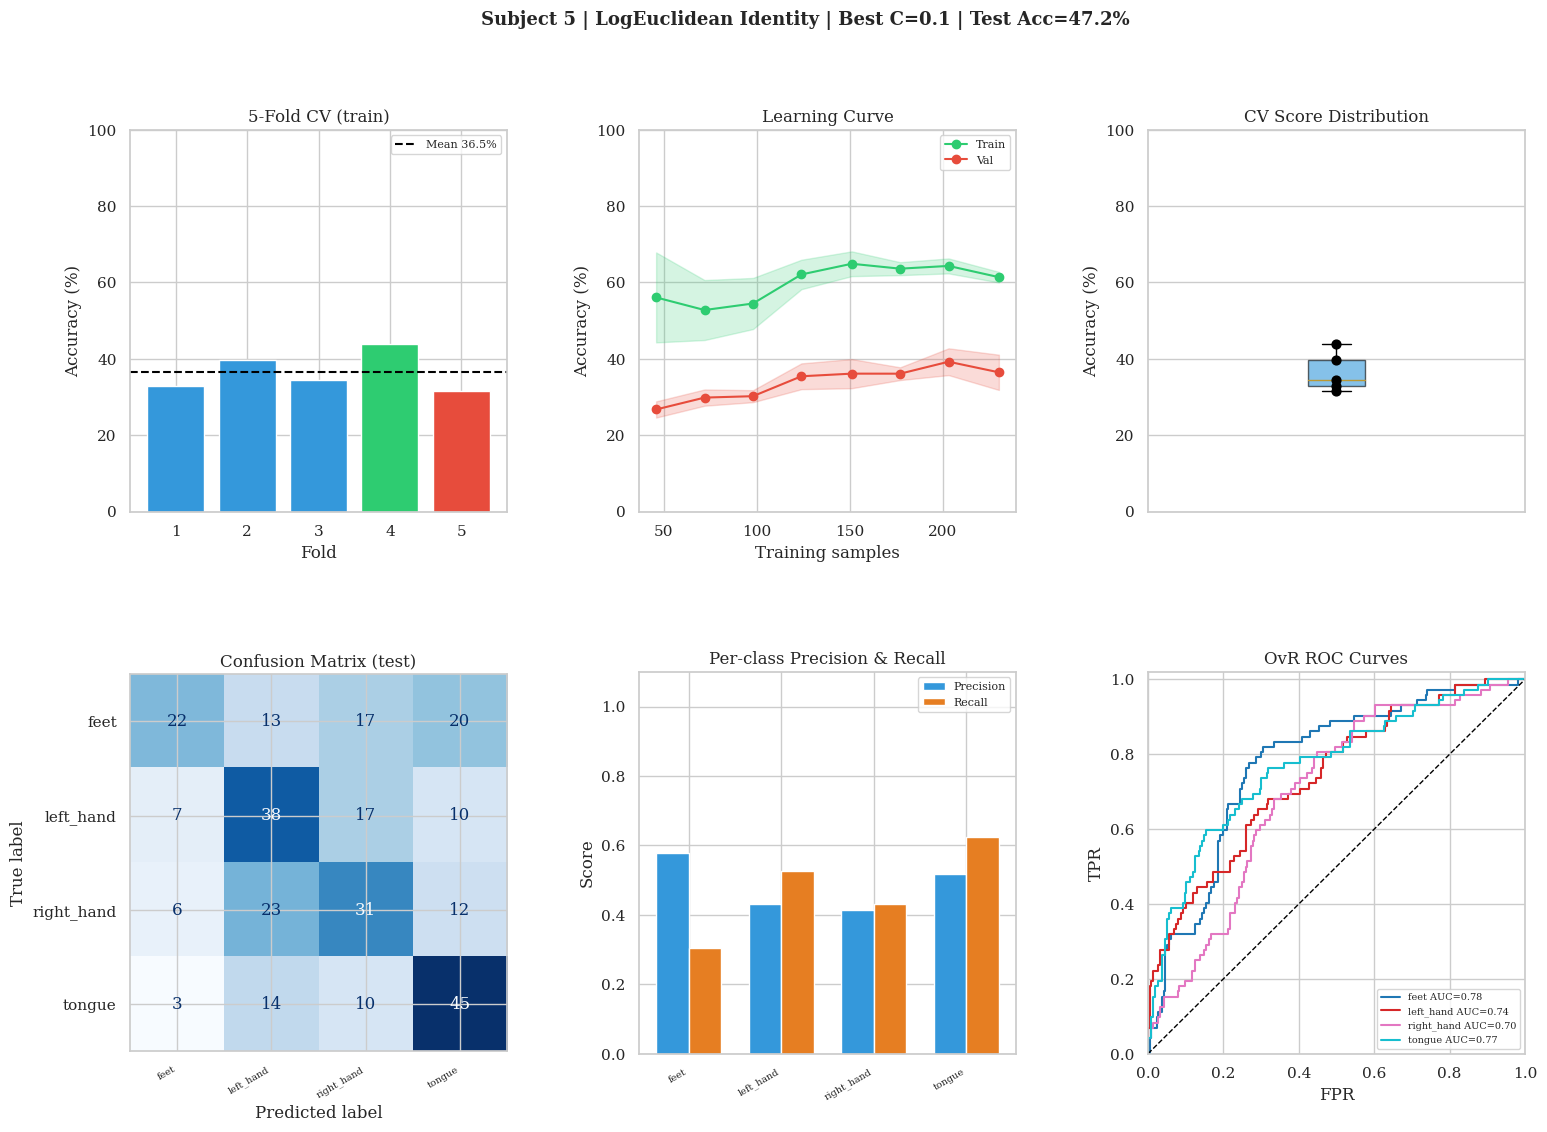

Subjects:  56%|█████▌    | 5/9 [03:15<02:50, 42.63s/it]

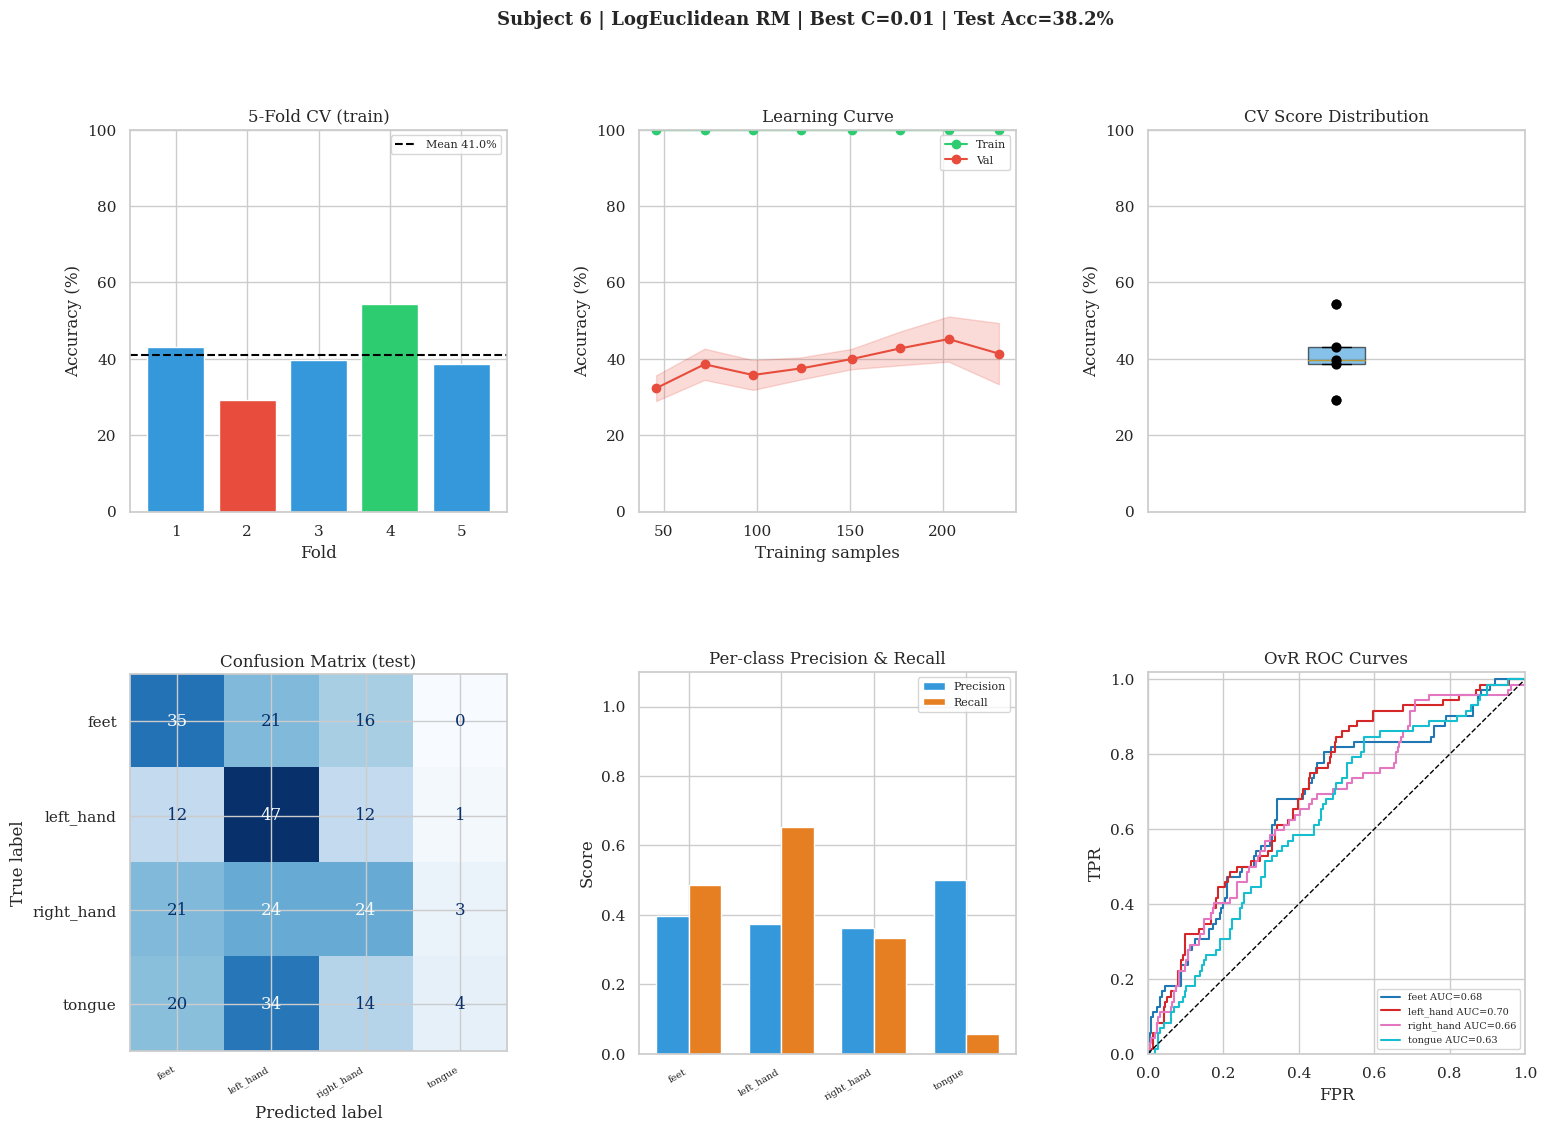

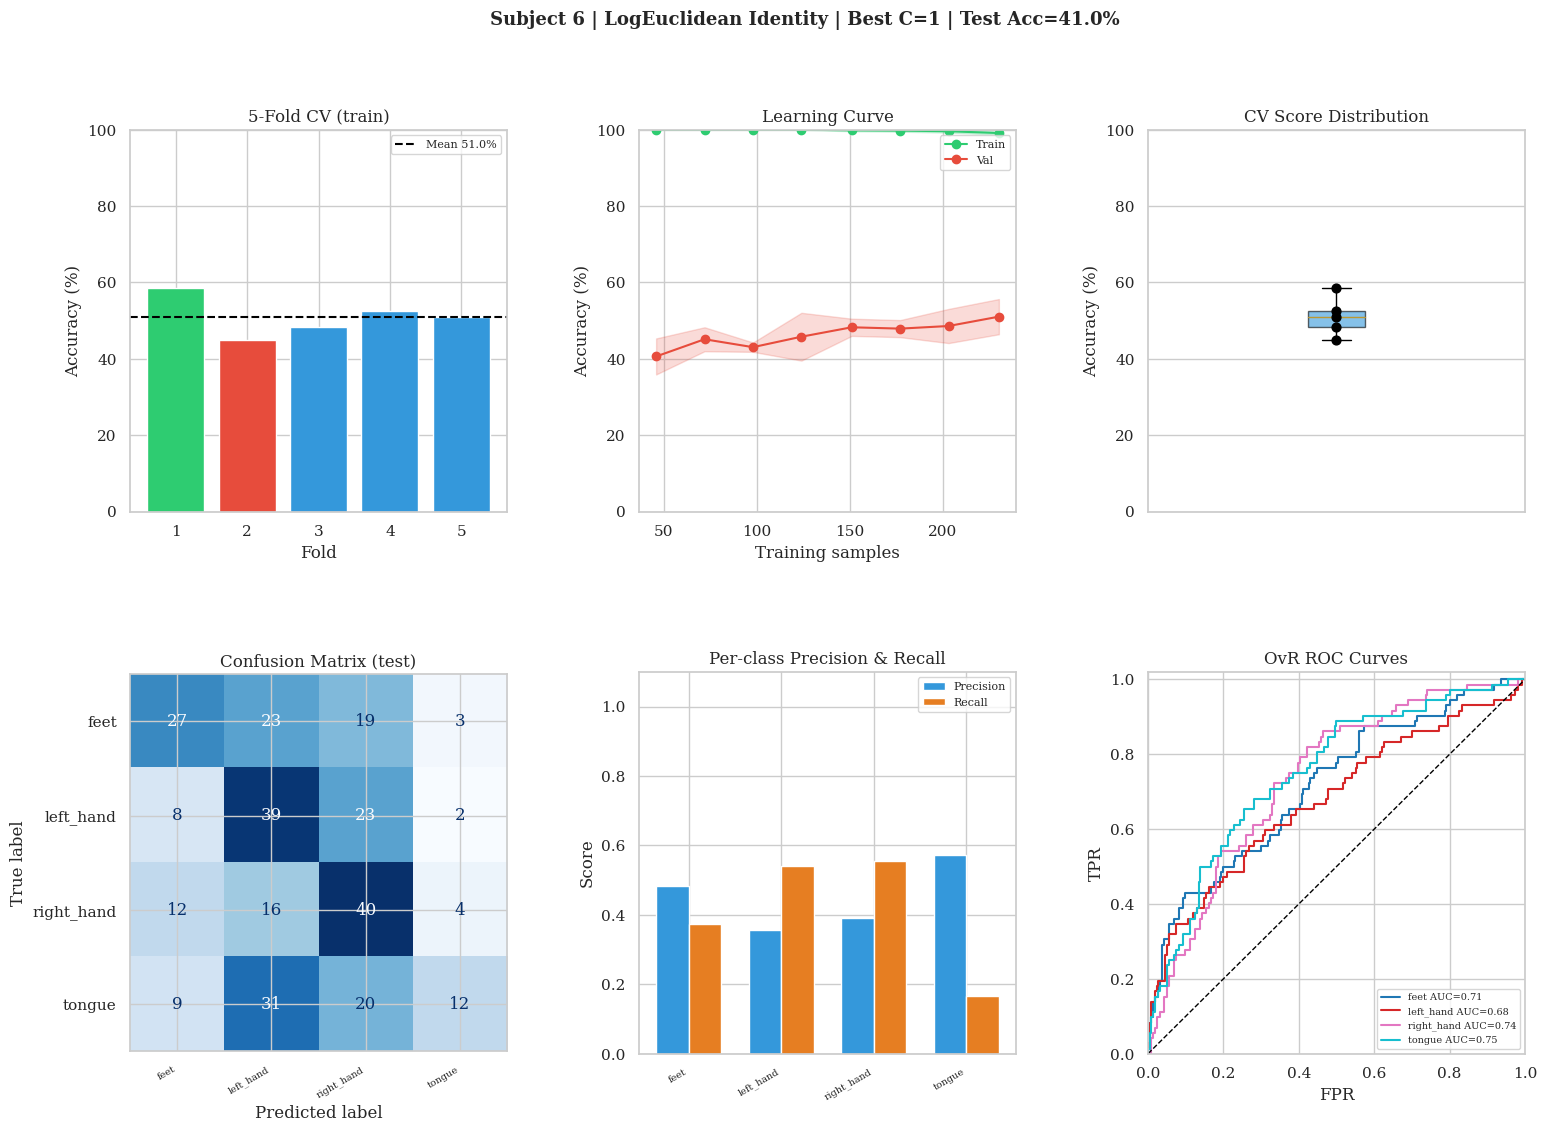

Subjects:  67%|██████▋   | 6/9 [03:44<01:53, 37.91s/it]

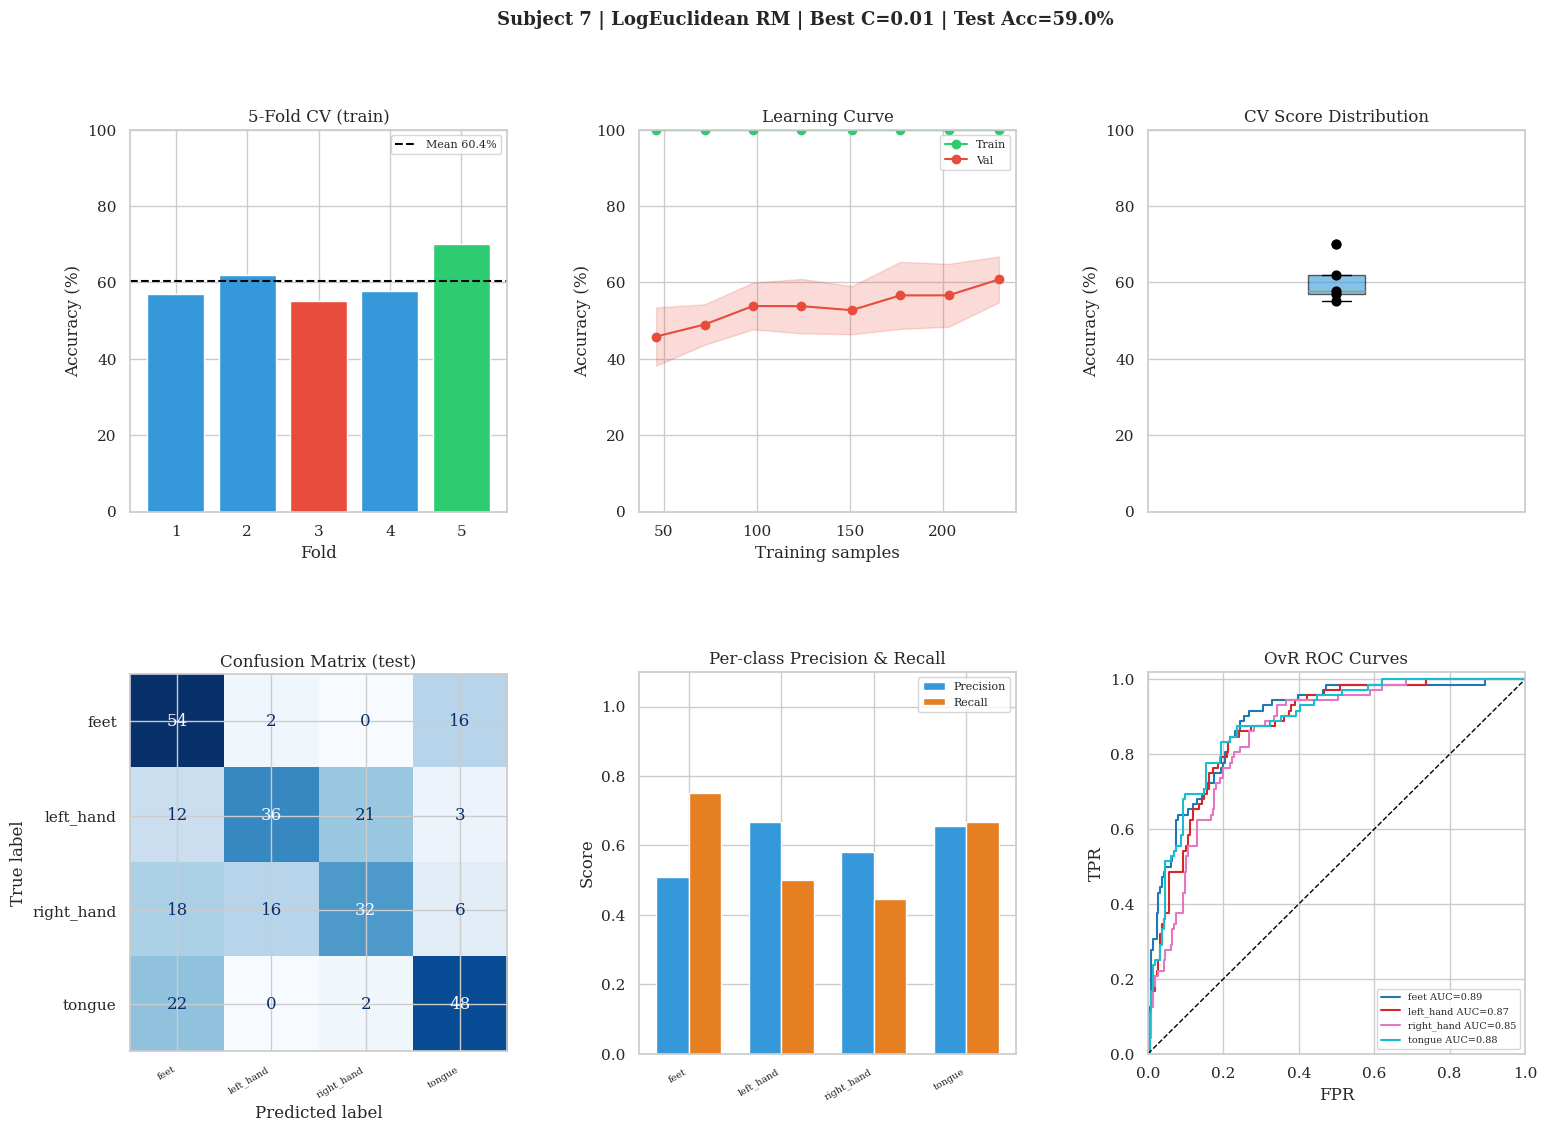

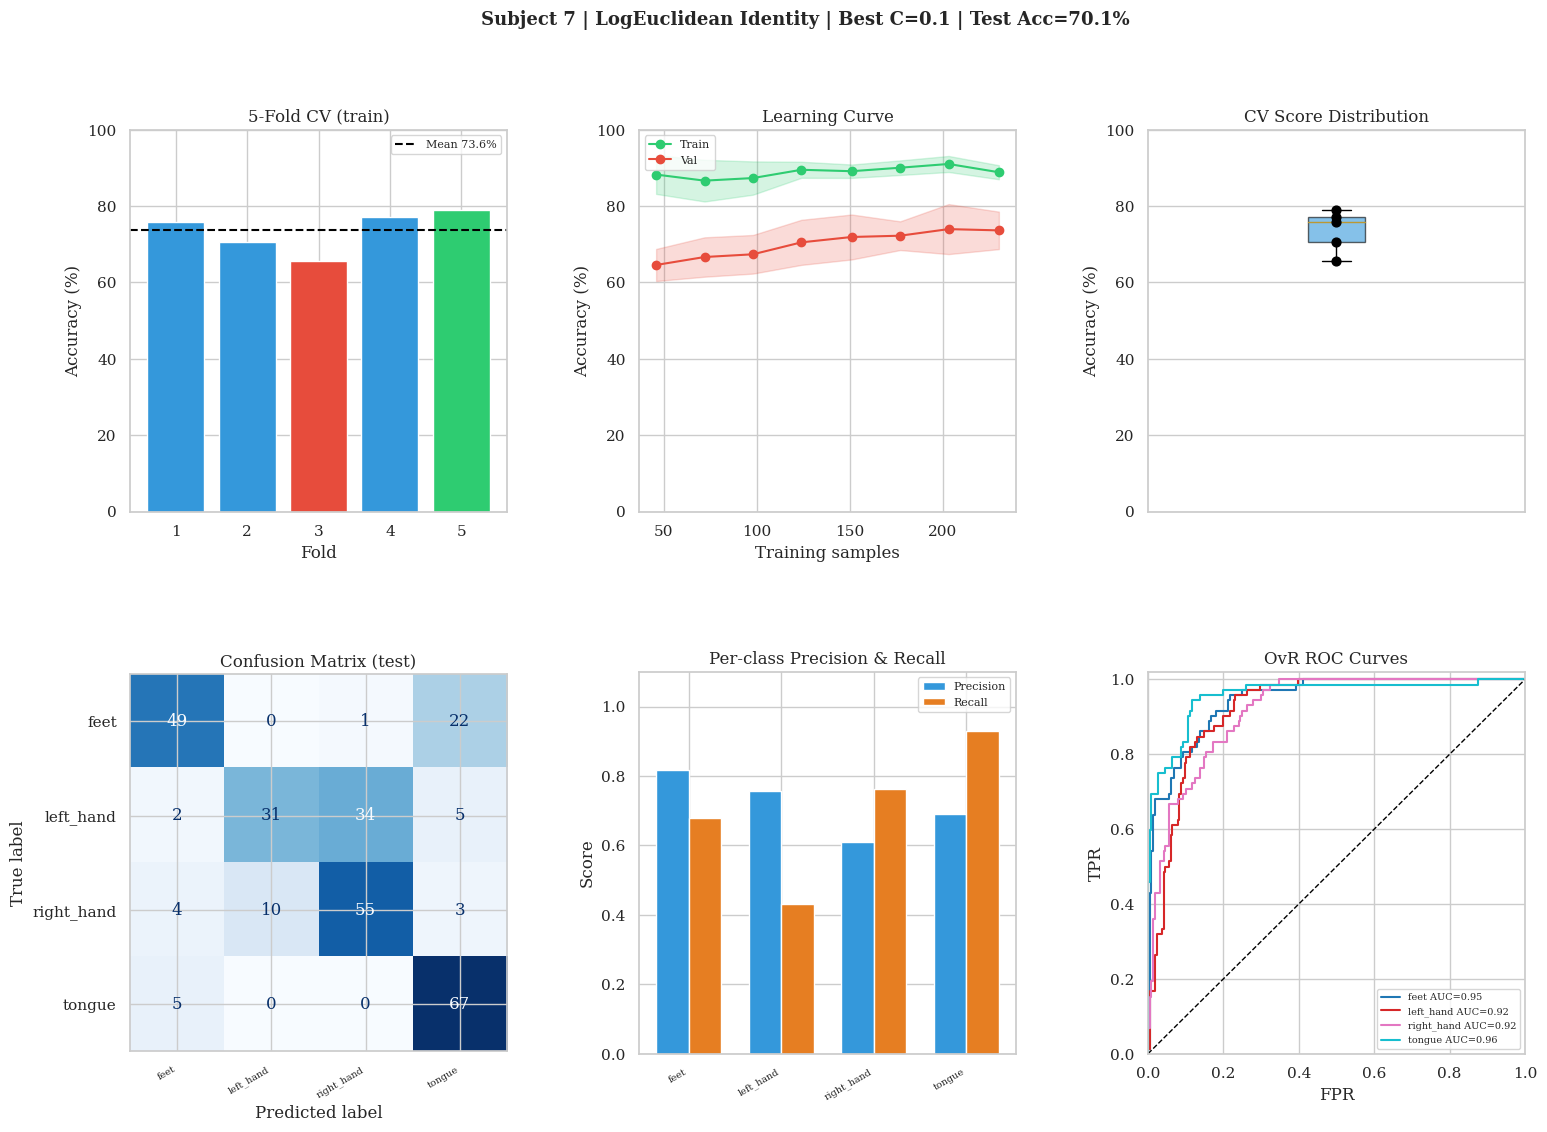

Subjects:  78%|███████▊  | 7/9 [04:10<01:08, 34.10s/it]

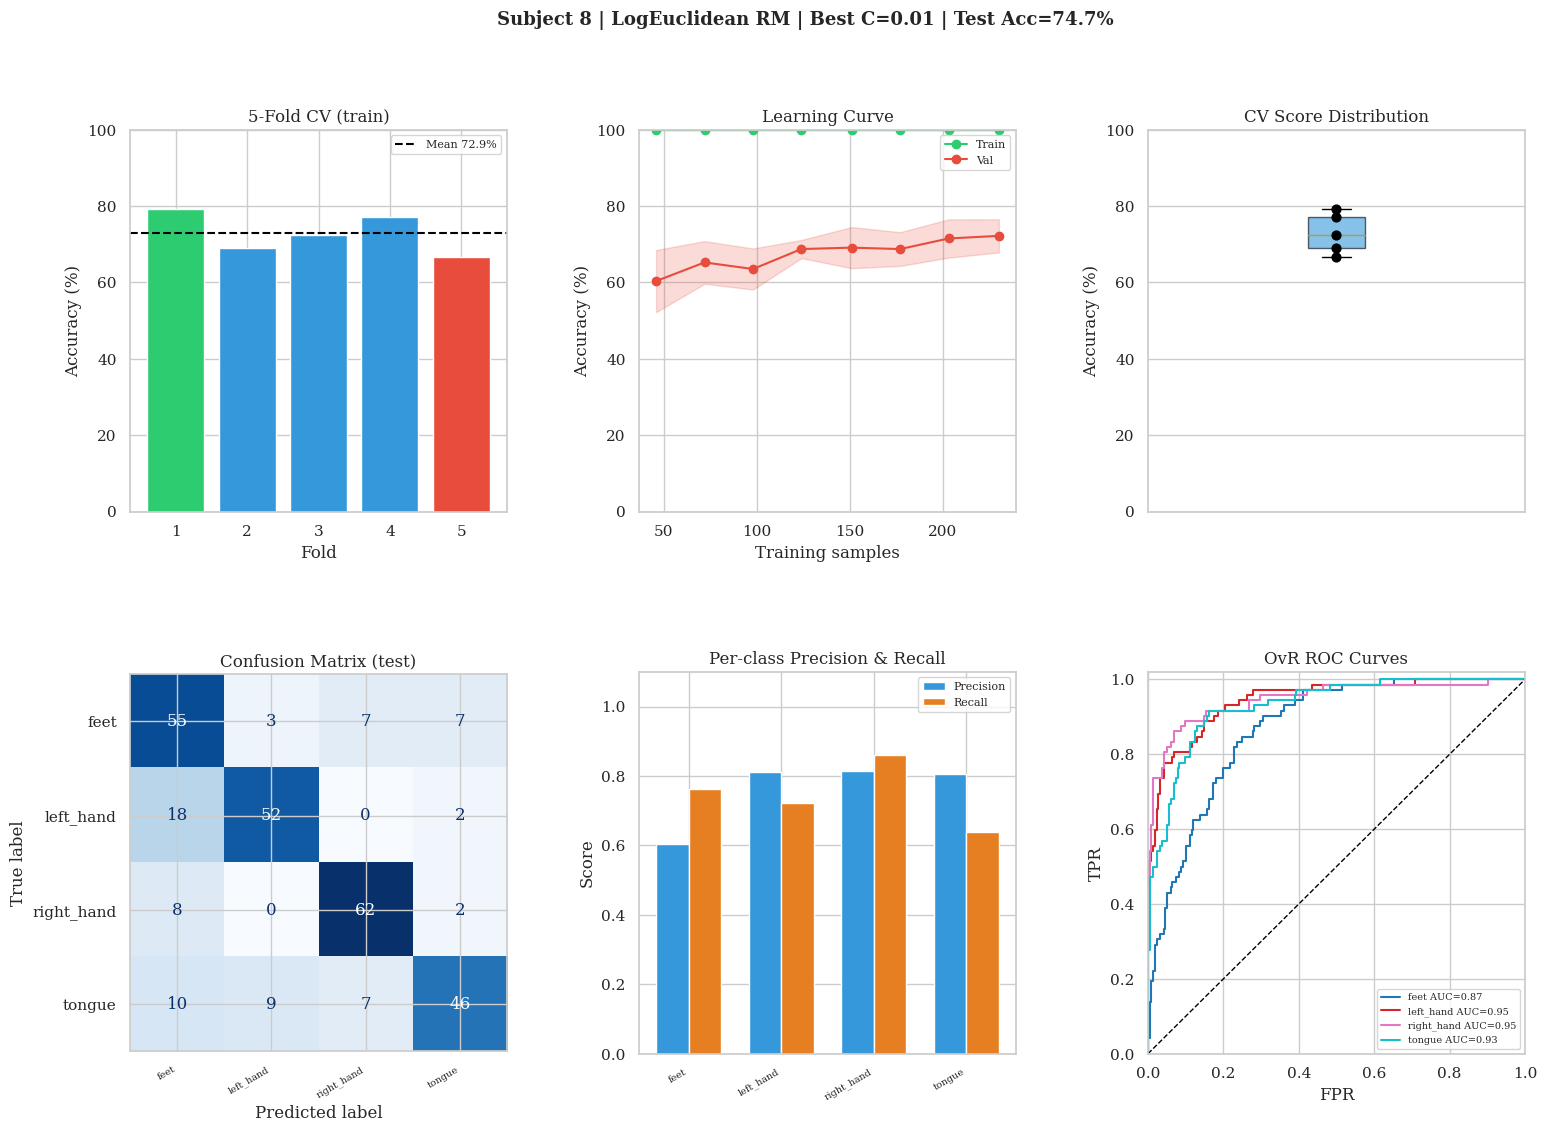

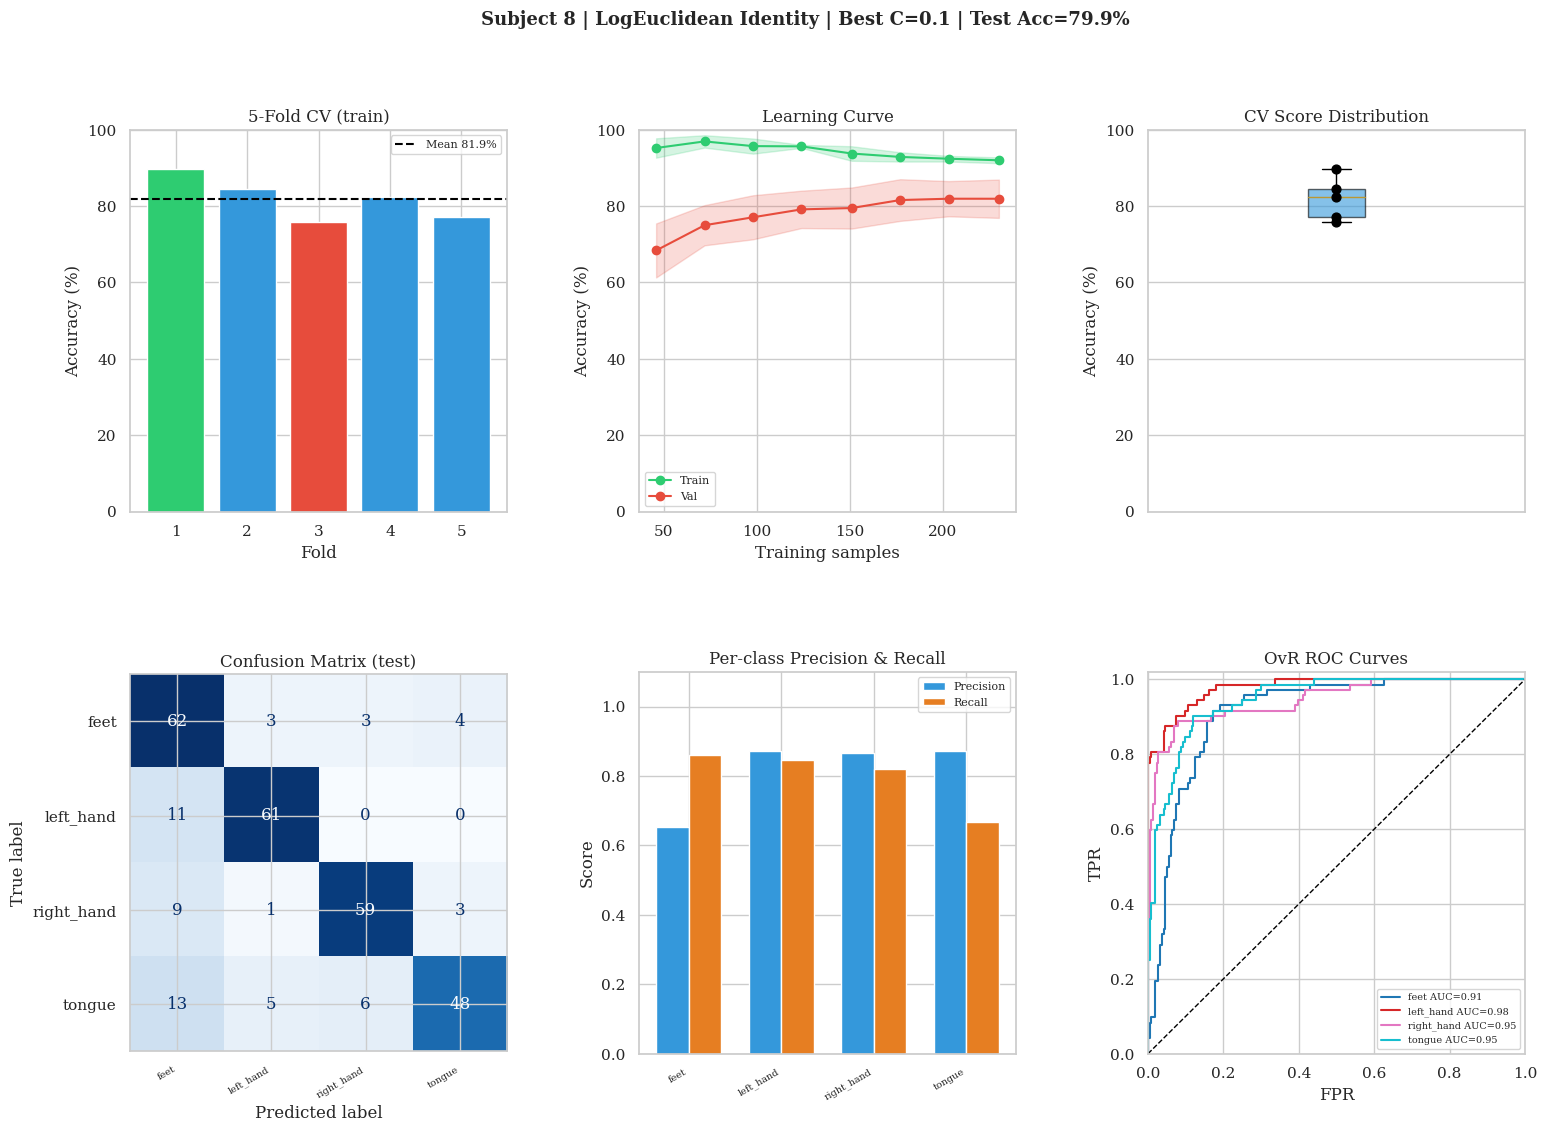

Subjects:  89%|████████▉ | 8/9 [04:34<00:30, 30.88s/it]

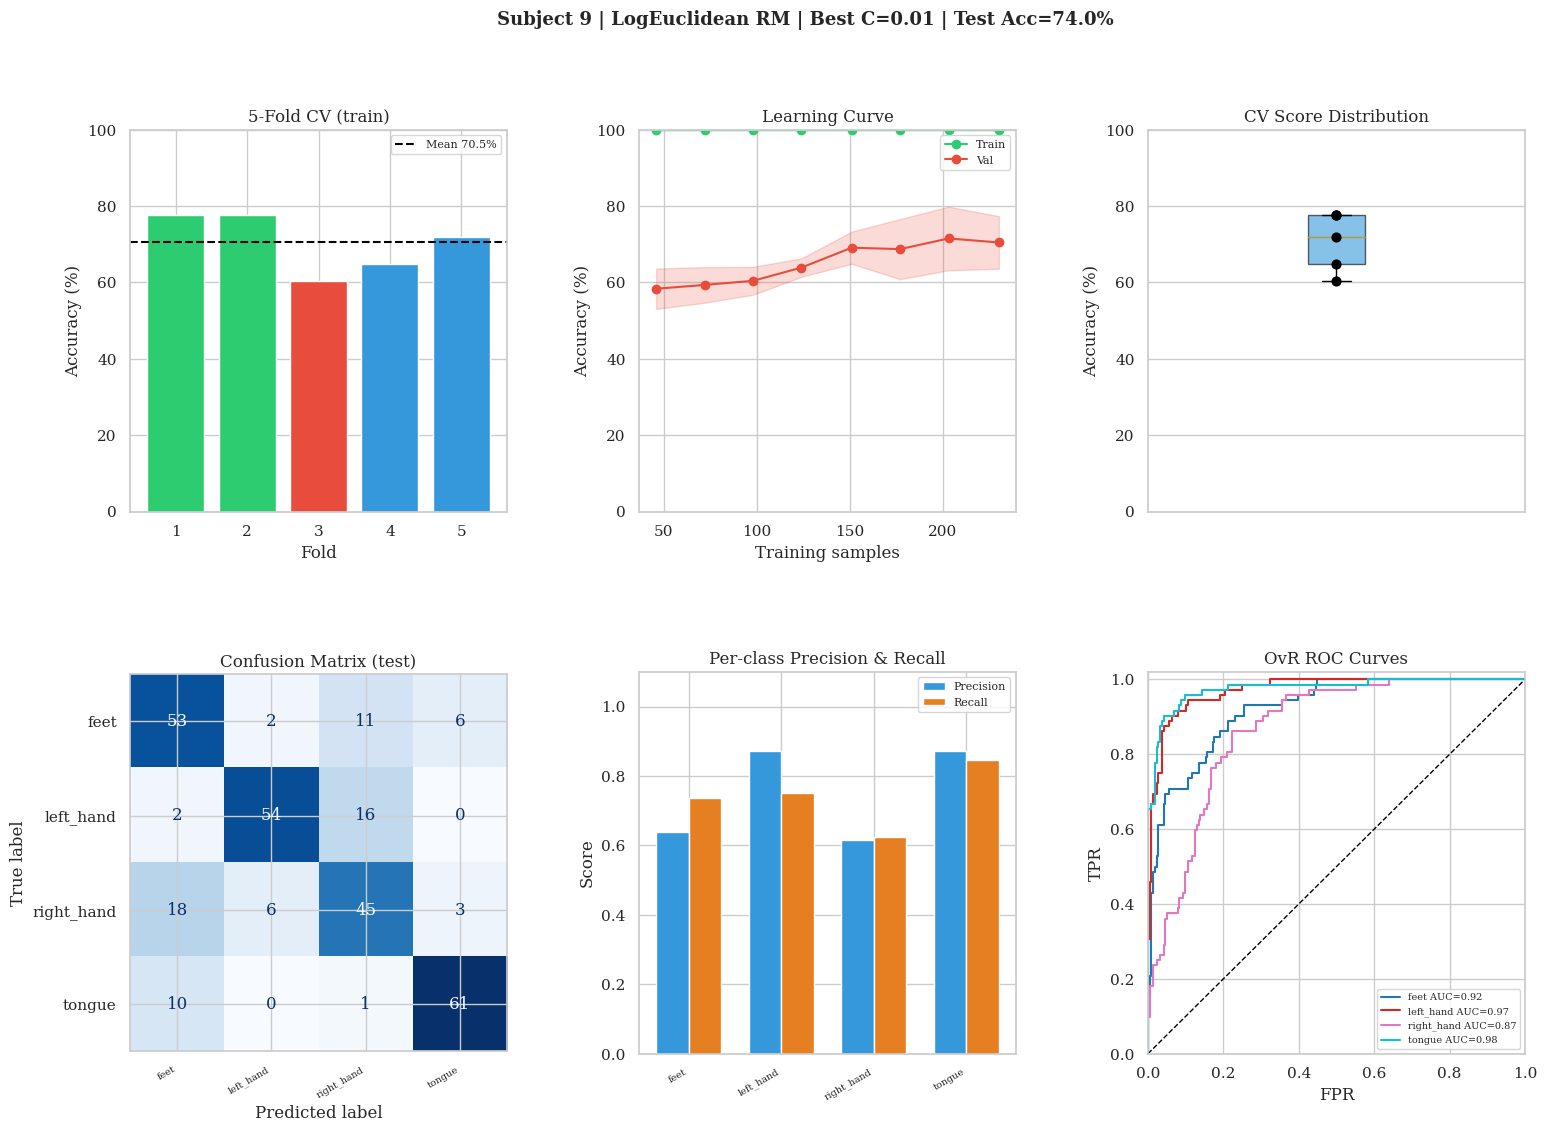

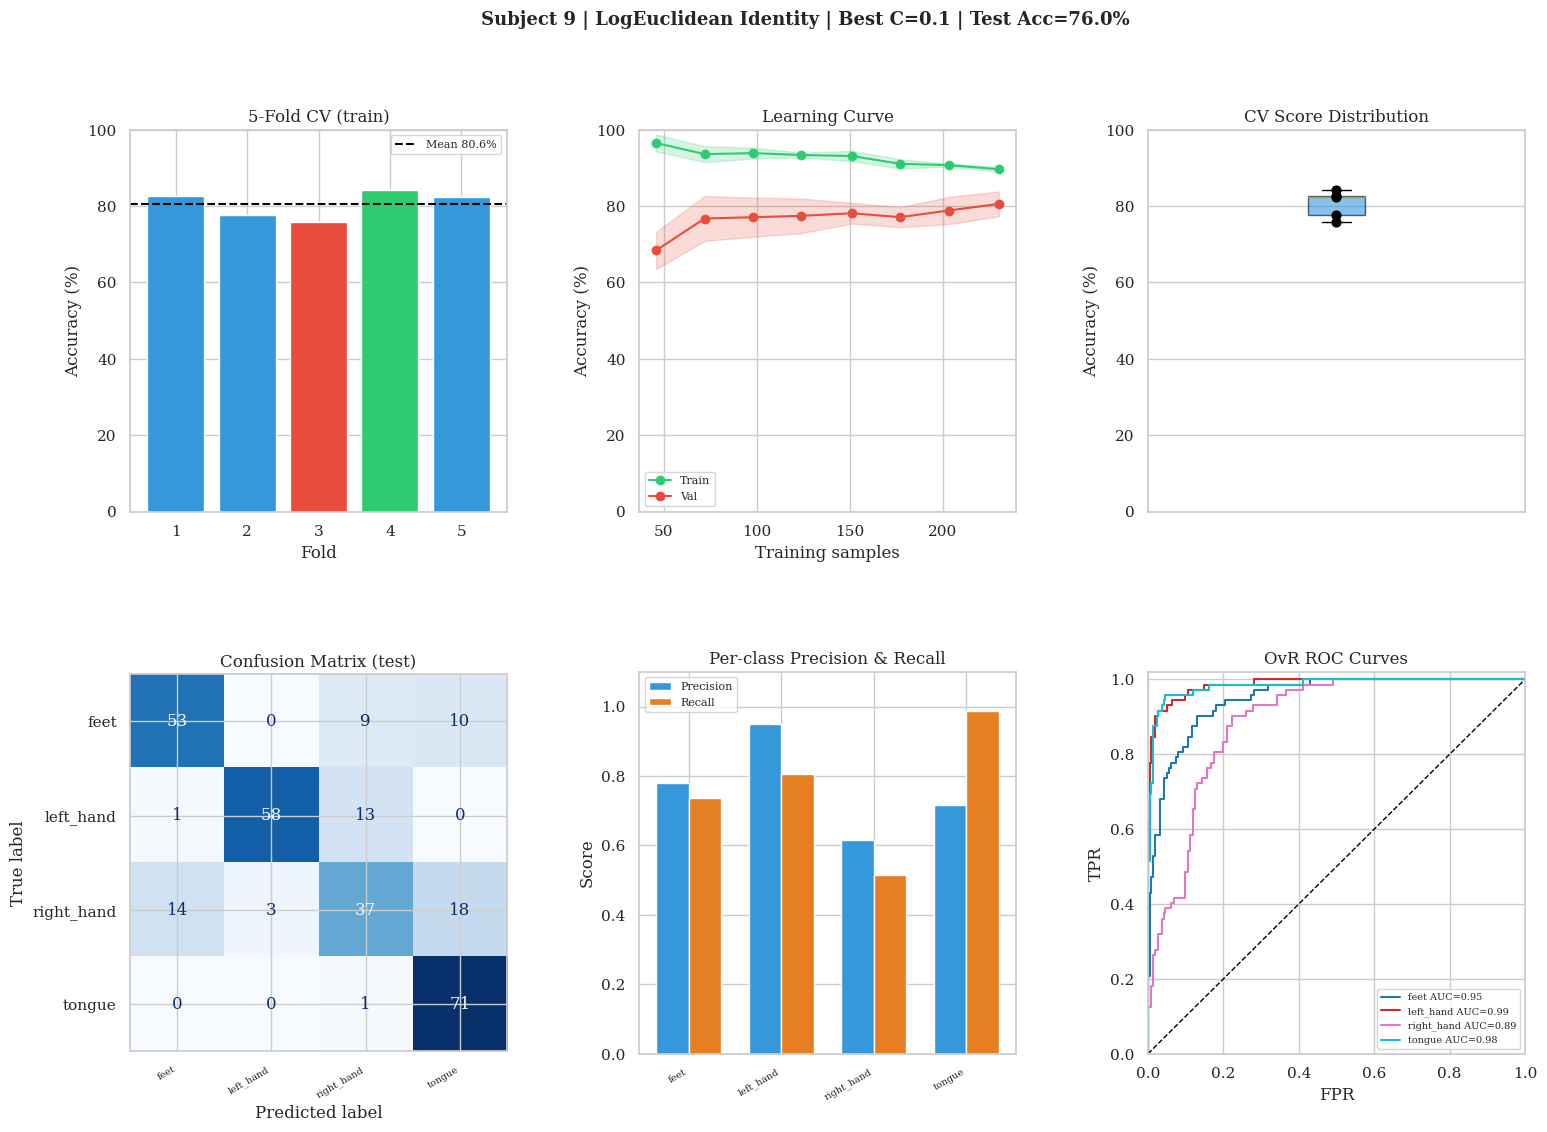

Subjects: 100%|██████████| 9/9 [04:58<00:00, 33.21s/it]


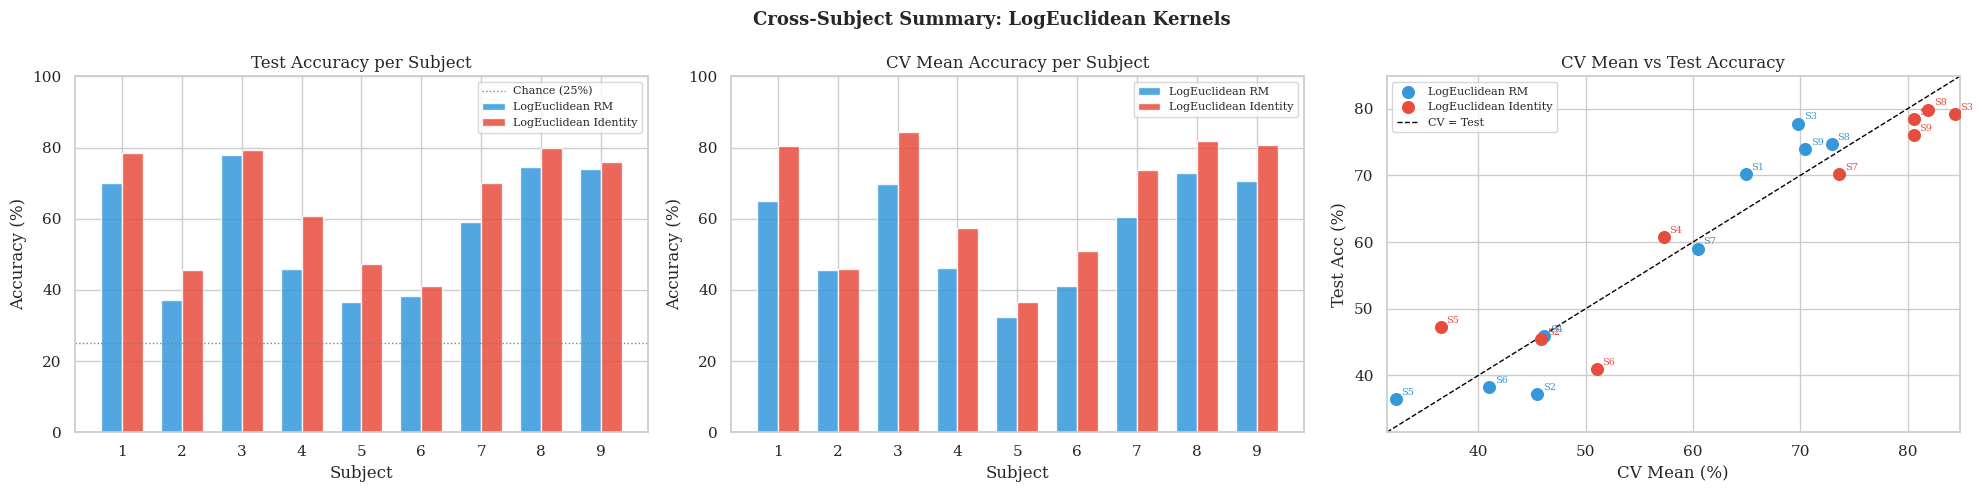


 Sub                   Kernel   Best C   CV Mean   CV Std   Test Acc
──────────────────────────────────────────────────────────────────────
   1          LogEuclidean RM     0.01     64.9%     4.9%      70.1%
   1    LogEuclidean Identity       10     80.6%     2.5%      78.5%
──────────────────────────────────────────────────────────────────────
   2          LogEuclidean RM     0.01     45.5%     3.6%      37.2%
   2    LogEuclidean Identity        1     45.8%     4.5%      45.5%
──────────────────────────────────────────────────────────────────────
   3          LogEuclidean RM     0.01     69.8%     6.8%      77.8%
   3    LogEuclidean Identity      0.1     84.4%     5.9%      79.2%
──────────────────────────────────────────────────────────────────────
   4          LogEuclidean RM     0.01     46.1%     8.3%      45.8%
   4    LogEuclidean Identity      0.1     57.3%     4.7%      60.8%
──────────────────────────────────────────────────────────────────────
   5          LogEuclid

In [17]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from pyriemann.estimation import Covariances
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.base import logm, sqrtm, invsqrtm
from tqdm import tqdm

# ── LogEuclidean Kernel Transformers ──────────────────────────────────────────

class LogEuclideanKernelRiemannianMean(BaseEstimator, TransformerMixin):
    """
    LogEuclidean kernel centered at the Riemannian mean G_RM of the training set.
    
    K(A, B) = <Log_{G_RM}(A), Log_{G_RM}(B)>_F
            = trace( Log_{G_RM}(A)^T  Log_{G_RM}(B) )

    where Log_{G_RM}(A) = G_RM^{1/2} logm(G_RM^{-1/2} A G_RM^{-1/2}) G_RM^{1/2}
    """
    def __init__(self):
        self.G_RM_ = None
        self.X_log_train_ = None

    def _log_map(self, X):
        """Map SPD matrices to tangent space at G_RM."""
        S  = self.sqrt_G_
        Si = self.invsqrt_G_
        # Vectorised: for each matrix A, compute S @ logm(Si @ A @ Si) @ S
        return np.array([S @ logm(Si @ A @ Si) @ S for A in X])

    def fit(self, X, y=None):
        self.G_RM_     = mean_riemann(X)
        self.sqrt_G_   = sqrtm(self.G_RM_)
        self.invsqrt_G_ = invsqrtm(self.G_RM_)
        self.X_log_train_ = self._log_map(X)          # (n_train, p, p)
        return self

    def transform(self, X):
        X_log = self._log_map(X)                       # (n_test, p, p)
        # Gram matrix: K[i,j] = <X_log[i], X_log_train_[j]>_F
        n_test  = X_log.shape[0]
        n_train = self.X_log_train_.shape[0]
        K = np.zeros((n_test, n_train))
        for i in range(n_test):
            for j in range(n_train):
                K[i, j] = np.tensordot(X_log[i], self.X_log_train_[j], axes=2)
        return K


class LogEuclideanKernelIdentity(BaseEstimator, TransformerMixin):
    """
    LogEuclidean kernel centered at the Identity matrix I.

    K(A, B) = <logm(A), logm(B)>_F  = trace( logm(A)^T logm(B) )

    This is the special case of the Riemannian-mean kernel when G_RM = I.
    """
    def __init__(self):
        self.X_log_train_ = None

    def fit(self, X, y=None):
        self.X_log_train_ = np.array([logm(A) for A in X])
        return self

    def transform(self, X):
        X_log   = np.array([logm(A) for A in X])
        n_test  = X_log.shape[0]
        n_train = self.X_log_train_.shape[0]
        K = np.zeros((n_test, n_train))
        for i in range(n_test):
            for j in range(n_train):
                K[i, j] = np.tensordot(X_log[i], self.X_log_train_[j], axes=2)
        return K


# ── Pipeline factories ────────────────────────────────────────────────────────

def make_pipeline_rm(c=1.0):
    """LogEuclidean kernel centred at Riemannian Mean."""
    return Pipeline([
        ('scaler', MicrovoltScaler()),
        ('cov',    Covariances(estimator='oas')),
        ('kernel', LogEuclideanKernelRiemannianMean()),
        ('svc',    SVC(kernel='precomputed', C=c, probability=True)),
    ])

def make_pipeline_id(c=1.0):
    """LogEuclidean kernel centred at Identity."""
    return Pipeline([
        ('scaler', MicrovoltScaler()),
        ('cov',    Covariances(estimator='oas')),
        ('kernel', LogEuclideanKernelIdentity()),
        ('svc',    SVC(kernel='precomputed', C=c, probability=True)),
    ])


# ── Evaluation helpers ────────────────────────────────────────────────────────

SUBJECTS   = list(range(1, 10))
N_SPLITS   = 5
PARAM_GRID = {'svc__C': [0.01, 0.1, 1, 10, 100]}

dataset  = BNCI2014001()
paradigm = ButterworthMotorImagery(fmin=8.0, fmax=30.0, tmin=0.5, tmax=2.5)


def evaluate_subject(subject, make_pipe_fn, label):
    X, y, metadata = paradigm.get_data(dataset, subjects=[subject])
    train_idx = metadata['session'] == '0train'
    test_idx  = metadata['session'] == '1test'
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=42)

    # 1. Grid-search best C
    grid = GridSearchCV(make_pipe_fn(), PARAM_GRID, cv=cv,
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_c = grid.best_params_['svc__C']

    # 2. Refit on ALL training data with best C
    pipe = make_pipe_fn(best_c)
    pipe.fit(X_train, y_train)

    # 3. Test evaluation
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    test_acc = (y_pred == y_test).mean()

    # 4. CV scores & learning curve on training set
    cv_scores = cross_val_score(make_pipe_fn(best_c), X_train, y_train,
                                cv=cv, scoring='accuracy')
    train_sizes, train_scores, val_scores = learning_curve(
        make_pipe_fn(best_c), X_train, y_train,
        cv=cv, train_sizes=np.linspace(0.2, 1.0, 8),
        scoring='accuracy', n_jobs=-1)

    return dict(subject=subject, label=label, best_c=best_c,
                test_acc=test_acc, cv_scores=cv_scores,
                y_test=y_test, y_pred=y_pred, y_prob=y_prob,
                pipe=pipe,
                train_sizes=train_sizes,
                train_scores=train_scores, val_scores=val_scores)


def plot_subject_diagnostics(r):
    subj  = r['subject']
    label = r['label']
    cv_scores    = r['cv_scores']
    test_acc     = r['test_acc']
    best_c       = r['best_c']
    y_test, y_pred, y_prob = r['y_test'], r['y_pred'], r['y_prob']
    train_sizes  = r['train_sizes']
    train_scores = r['train_scores']
    val_scores   = r['val_scores']
    pipe         = r['pipe']

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'Subject {subj} | {label} | Best C={best_c} | Test Acc={test_acc*100:.1f}%',
                 fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    # (a) K-fold bar
    ax0 = fig.add_subplot(gs[0, 0])
    colors = ['#e74c3c' if s == cv_scores.min() else
              '#2ecc71' if s == cv_scores.max() else '#3498db'
              for s in cv_scores]
    ax0.bar(range(1, N_SPLITS+1), cv_scores*100, color=colors, edgecolor='white')
    ax0.axhline(cv_scores.mean()*100, color='k', ls='--', lw=1.5,
                label=f'Mean {cv_scores.mean()*100:.1f}%')
    ax0.set(title=f'{N_SPLITS}-Fold CV (train)', xlabel='Fold', ylabel='Accuracy (%)')
    ax0.set_ylim(0, 100); ax0.legend(fontsize=8)

    # (b) Learning curve
    ax1 = fig.add_subplot(gs[0, 1])
    tr_m = train_scores.mean(1)*100; tr_s = train_scores.std(1)*100
    va_m = val_scores.mean(1)*100;   va_s = val_scores.std(1)*100
    ax1.plot(train_sizes, tr_m, 'o-', color='#2ecc71', label='Train')
    ax1.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.2, color='#2ecc71')
    ax1.plot(train_sizes, va_m, 'o-', color='#e74c3c', label='Val')
    ax1.fill_between(train_sizes, va_m-va_s, va_m+va_s, alpha=0.2, color='#e74c3c')
    ax1.set(title='Learning Curve', xlabel='Training samples', ylabel='Accuracy (%)')
    ax1.set_ylim(0, 100); ax1.legend(fontsize=8)

    # (c) CV distribution
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.boxplot(cv_scores*100, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax2.scatter([1]*N_SPLITS, cv_scores*100, color='k', zorder=5, s=40)
    ax2.set(title='CV Score Distribution', ylabel='Accuracy (%)', xticks=[])
    ax2.set_ylim(0, 100)

    # (d) Confusion matrix
    ax3 = fig.add_subplot(gs[1, 0])
    present = np.unique(np.concatenate([y_test, y_pred]))
    cm   = confusion_matrix(y_test, y_pred, labels=present)
    disp = ConfusionMatrixDisplay(cm, display_labels=present)
    disp.plot(ax=ax3, colorbar=False, cmap='Blues')
    ax3.set_title('Confusion Matrix (test)')
    plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=7)

    # (e) Per-class precision / recall
    ax4 = fig.add_subplot(gs[1, 1])
    report    = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cls_labels = [k for k in report if k not in ('accuracy','macro avg','weighted avg')]
    prec = [report[c]['precision'] for c in cls_labels]
    rec  = [report[c]['recall']    for c in cls_labels]
    x = np.arange(len(cls_labels)); w = 0.35
    ax4.bar(x-w/2, prec, w, label='Precision', color='#3498db')
    ax4.bar(x+w/2, rec,  w, label='Recall',    color='#e67e22')
    ax4.set(title='Per-class Precision & Recall', ylabel='Score',
            xticks=x, xticklabels=cls_labels)
    plt.setp(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    ax4.set_ylim(0, 1.1); ax4.legend(fontsize=8)

    # (f) OvR ROC
    ax5 = fig.add_subplot(gs[1, 2])
    unique_classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=unique_classes)
    cmap  = plt.cm.get_cmap('tab10', len(unique_classes))
    for i, cls in enumerate(unique_classes):
        col_idx = list(pipe.classes_).index(cls)
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, col_idx])
        ax5.plot(fpr, tpr, color=cmap(i), lw=1.5,
                 label=f'{cls} AUC={auc(fpr,tpr):.2f}')
    ax5.plot([0,1],[0,1],'k--',lw=1)
    ax5.set(title='OvR ROC Curves', xlabel='FPR', ylabel='TPR')
    ax5.set_xlim(0,1); ax5.set_ylim(0,1.02)
    ax5.legend(fontsize=7, loc='lower right')

    plt.savefig(f'subject_{subj}_{label.replace(" ","_")}_diagnostics.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# ── Main loop ─────────────────────────────────────────────────────────────────

configs = [
    (make_pipeline_rm, 'LogEuclidean RM'),
    (make_pipeline_id, 'LogEuclidean Identity'),
]

all_results = {label: [] for _, label in configs}

for subject in tqdm(SUBJECTS, desc='Subjects'):
    for make_pipe_fn, label in configs:
        r = evaluate_subject(subject, make_pipe_fn, label)
        all_results[label].append(r)
        plot_subject_diagnostics(r)


# ── Cross-subject summary (both kernels side-by-side) ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Cross-Subject Summary: LogEuclidean Kernels', fontsize=13, fontweight='bold')

colors_map = {
    'LogEuclidean RM':       '#3498db',
    'LogEuclidean Identity': '#e74c3c',
}
x = np.arange(len(SUBJECTS)); w = 0.35

# (1) Test accuracy per subject
ax = axes[0]
for offset, (_, label) in zip([-w/2, w/2], configs):
    accs = [r['test_acc']*100 for r in all_results[label]]
    ax.bar(x + offset, accs, w, label=label, color=colors_map[label], alpha=0.85)
ax.axhline(25, color='gray', ls=':', lw=1, label='Chance (25%)')
ax.set(title='Test Accuracy per Subject', xlabel='Subject', ylabel='Accuracy (%)',
       xticks=x, xticklabels=SUBJECTS)
ax.set_ylim(0, 100); ax.legend(fontsize=8)

# (2) CV mean per subject
ax = axes[1]
for offset, (_, label) in zip([-w/2, w/2], configs):
    cv_means = [r['cv_scores'].mean()*100 for r in all_results[label]]
    ax.bar(x + offset, cv_means, w, label=label, color=colors_map[label], alpha=0.85)
ax.set(title='CV Mean Accuracy per Subject', xlabel='Subject', ylabel='Accuracy (%)',
       xticks=x, xticklabels=SUBJECTS)
ax.set_ylim(0, 100); ax.legend(fontsize=8)

# (3) CV mean vs Test accuracy scatter (both kernels)
ax = axes[2]
for _, label in configs:
    cv_means = [r['cv_scores'].mean()*100 for r in all_results[label]]
    accs     = [r['test_acc']*100         for r in all_results[label]]
    ax.scatter(cv_means, accs, s=70, color=colors_map[label], label=label, zorder=5)
    for i, s in enumerate(SUBJECTS):
        ax.annotate(f'S{s}', (cv_means[i], accs[i]),
                    textcoords='offset points', xytext=(4, 3), fontsize=7,
                    color=colors_map[label])
all_accs = [r['test_acc']*100 for lbl in all_results for r in all_results[lbl]]
mn, mx = min(all_accs)-5, max(all_accs)+5
ax.plot([mn,mx],[mn,mx],'k--',lw=1,label='CV = Test')
ax.set(title='CV Mean vs Test Accuracy', xlabel='CV Mean (%)', ylabel='Test Acc (%)')
ax.set_xlim(mn,mx); ax.set_ylim(mn,mx); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('summary_both_kernels.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────

print(f"\n{'Sub':>4} {'Kernel':>24} {'Best C':>8} {'CV Mean':>9} {'CV Std':>8} {'Test Acc':>10}")
print("─" * 70)
for subject in SUBJECTS:
    for _, label in configs:
        r = next(x for x in all_results[label] if x['subject'] == subject)
        print(f"{r['subject']:>4} {label:>24} {r['best_c']:>8} "
              f"{r['cv_scores'].mean()*100:>8.1f}% "
              f"{r['cv_scores'].std()*100:>7.1f}% "
              f"{r['test_acc']*100:>9.1f}%")
    print("─" * 70)

for _, label in configs:
    accs = [r['test_acc'] for r in all_results[label]]
    print(f"  {label:>24} Mean Test Acc: {np.mean(accs)*100:.1f}%  Std: {np.std(accs)*100:.1f}%")